# SWaT ICS Anomaly Detection — PyTorch Pipeline v5.0 (Overfitting + Variable Fixes Applied)
**Author:** Dweep Vira | **System:** SWaT Digital Twin | **Date:** May 2026 (v4 fixes)

---

## Architecture (v3 — Full Failure Analysis Applied + Autoencoder Added)

### Four-Layer Ensemble
| Layer | Model | Role | Training Data |
|---|---|---|---|
| 1a | Isolation Forest | Normal manifold score (feature for XGBoost) | Normal-only |
| 1b | **Autoencoder (NEW)** | Reconstruction error anomaly score | Normal-only |
| 2 | XGBoost | Primary backbone classifier (binary) | Full labelled dataset |
| 3 | CNN-BiLSTM + Attention | Temporal refiner on flagged windows | Full dataset |

### v3 vs v2 Changes (from complete_failure_analysis.md)
| Issue | v2 | v3 Fix |
|---|---|---|
| **Autoencoder missing** | Not implemented | **Added: 128→64→32→64→128 PyTorch AE** |
| IF used as voting layer (F1=0.09) | IF binary vote | IF score → XGBoost feature (augmented) |
| IF FPR target too tight | 0.03 | 0.08 (better recall trade-off) |
| XGBoost SMOTE fake frozen samples | BorderlineSMOTE | `scale_pos_weight` (research report plan) |
| XGBoost binary:logistic discarded | multi:softprob | `binary:logistic` + `eval_metric=aucpr` |
| XGB early stop at 72/500 | max_depth=7, lr=0.05 | max_depth=5, lr=0.03, n_estimators=800 |
| CNN total collapse (F1=0.06) | Adam lr=1e-3 | Adam lr=3e-4, clipnorm=1.0 |
| CNN EarlyStopping fired at epoch 9 | patience=8, val_loss | patience=15, val_auc (correct metric) |
| CNN ReduceLR wrong monitor | val_loss | val_auc, mode=max, patience=5 |
| CNN epochs too low | 50 | 80 |
| Ensemble majority vote (F1=0.14) | 3-way majority | Weighted soft score + calibrated threshold |
| Thresholds hardcoded | XGB=0.70, CNN=0.50 | All calibrated on val F1 |


---
## Cell 0 — Install (run once in `swat_ml` env)

In [3]:
# import subprocess, sys

# # A6000 (Ampere CC 8.6) — use PyTorch 2.x with CUDA 12.1
# # Run this cell ONCE, then restart kernel
# TORCH_WHEEL = (
#     "torch torchvision torchaudio"
#     " --index-url https://download.pytorch.org/whl/cu121"
# )
# OTHER = [
#     "xgboost>=2.0.3", "scikit-learn>=1.3.2",
#     "imbalanced-learn>=0.11.0", "shap>=0.43.0", "pandas>=1.5.3",
#     "matplotlib>=3.7.5", "seaborn>=0.13.2", "scipy>=1.11.4", "joblib>=1.3.2",
# ]
# # subprocess.check_call(f"{sys.executable} -m pip install {TORCH_WHEEL} -q", shell=True)
# # for pkg in OTHER:
# #     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
# # print("Done — restart kernel now.")
# print("Uncomment lines above and run once, then restart kernel.")


---
## Cell 1 — Imports & GPU Configuration

In [5]:
import os, sys, gc, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from pathlib import Path
from scipy.optimize import minimize

# sklearn
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score,
    average_precision_score, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap

# PyTorch — 1.12.1 is last version supporting CC 3.5 (GT 730 Kepler)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device setup (A6000 / Ampere) ─────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    props  = torch.cuda.get_device_properties(0)
    vram   = props.total_memory // (1024**2)
    cc     = f"{props.major}.{props.minor}"
    print(f"[GPU] {props.name} | CC {cc} | VRAM {vram} MB | PyTorch {torch.__version__}")
    # A6000 = Ampere CC 8.6 — full support for PyTorch 2.x and XGBoost 2.x GPU
    USE_AMP = (props.major >= 8)  # BF16 / AMP only reliable on Ampere+
    print(f"[GPU] AMP (mixed precision): {'ENABLED (Ampere+)' if USE_AMP else 'DISABLED'}")
else:
    DEVICE = torch.device("cpu")
    USE_AMP = False
    print("[GPU] CUDA not available — using CPU.")

# A6000: XGBoost can use CUDA directly
XGB_DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
XGB_TREE_METHOD = "hist"   # hist works on both CPU and GPU in XGB 2.x
XGB_N_JOBS      = -1       # ignored on GPU but harmless
print(f"[XGB] device={XGB_DEVICE} | tree_method={XGB_TREE_METHOD}")
print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__} | XGB {xgb.__version__}")


[GPU] NVIDIA RTX A6000 | CC 8.6 | VRAM 49139 MB | PyTorch 2.7.0+cu128
[GPU] AMP (mixed precision): ENABLED (Ampere+)
[XGB] device=cuda | tree_method=hist
Python 3.11.15 | PyTorch 2.7.0+cu128 | XGB 3.2.0


---
## Cell 2 — Configuration (v3: all thresholds dynamic, IF→XGB feature)

**v3 changes:**
- `IF_FPR_TARGET = 0.08` (was 0.03 — too conservative, 3.5% attack recall)
- All thresholds (`XGB_THRESHOLD`, `CNN_THRESHOLD`, `ENS_THRESHOLD`) = `None` → calibrated on val
- `SMOTE_CAP` removed — using `scale_pos_weight` instead


In [7]:
NORMAL_PATH = "E:\\hydro_data\\normal_24h_hw\\normal_24h_hw\\master_dataset.csv"
ATTACK_PATH = "E:\\hydro_data\\attack_24h_hw\\attack_24h_hw\\master_dataset.csv"
HZ, EXPECTED_DT = 10, 0.1
CHUNKSIZE = 50_000

# SEQ_LEN=150: Slow Ramp at 0.007 pH/s needs 15s window to accumulate detectable drift
# At 30 steps (3s): delta_pH = 0.021 — inside noise floor
# At 150 steps (15s): delta_pH = 0.105 — clearly above noise
SEQ_LEN    = 150
BATCH_SIZE = 4096   # A6000 48 GB VRAM: 256 × 150 × 245 × 4 bytes ≈ 37 MB/batch — well within budget
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

# v3 FIX: IF_FPR_TARGET=0.08 (was 0.03 — threshold too conservative → 3.5% recall)
IF_FPR_TARGET = 0.08

# v3 FIX: All thresholds calibrated dynamically on validation F1 — not hardcoded
XGB_THRESHOLD = None   # calibrated in Layer 2
AE_THRESHOLD  = None   # calibrated in Layer 1b
CNN_THRESHOLD = None   # calibrated in Layer 3
ENS_THRESHOLD = None   # calibrated in Ensemble

ROLL_W = 20   # base rolling window for sensor stats

LAG_COLS = [
    "LIT_101","AIT_202","FIT_101","DPIT_301","PIT_501",
    "UF_Fouling_Factor","UF_Backwash_Active","UF_Last_Backwash",
    "Acid_Tank_Level","Chlorine_Tank_Level","Bisulfate_Tank_Level",
    "MV_101","MV_301","AIT_402",
]
LAG_STEPS = [1, 5, 10, 30, 100]

ATTACK_TYPE_MAP = {
    0:"normal",          8:"tank_overflow",    9:"valve_manipulation",
    10:"reconnaissance", 11:"ph_manipulation", 12:"membrane_damage",
    13:"chemical_depletion", 14:"slow_ramp",   15:"replay",
    16:"dos_flood"
}

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

print(f"SEQ_LEN  : {SEQ_LEN} steps = {SEQ_LEN*EXPECTED_DT:.1f}s")
print(f"IF_FPR   : {IF_FPR_TARGET*100:.0f}% (was 3% — too tight → 3.5% attack recall)")
print(f"Thresholds: all dynamic (calibrated on val F1)")
print(f"XGB mode : binary:logistic + scale_pos_weight (no SMOTE)")

# A6000 GPU overrides (set here, applied in relevant cells)
DATALOADER_WORKERS = 4          # parallel CPU workers for DataLoader prefetch
MAX_TRAIN_WINDOWS  = 1_000_000  # A6000 can handle full dataset — no subsampling needed


SEQ_LEN  : 150 steps = 15.0s
IF_FPR   : 8% (was 3% — too tight → 3.5% attack recall)
Thresholds: all dynamic (calibrated on val F1)
XGB mode : binary:logistic + scale_pos_weight (no SMOTE)


---
## Cell 3 — Memory-Safe Chunked Data Loading

In [9]:
BINARY_COLS = {
    "P_101","P_102","P_201","P_202","P_203","P_204","P_205","P_206",
    "P_301","P_302","P_401","P_402","P_403","P_404","P_501","P_502",
    "P_601","P_602","P_603","UV_401",
    "MV_101","MV_201","MV_301","MV_302","MV_303","MV_304",
    "UF_Backwash_Active","RO_Cleaning_Active","Chemical_Low_Alarm",
    "High_Fouling_Alarm","High_Level_Alarm","High_Pressure_Alarm",
    "System_Run","Energy_Monitor_Enable",
}
DROP_COLS = {
    "Energy_P101","Energy_P301","Energy_P501","Energy_Total",
    "PIT_503",   # r=1.0 with PIT_501
    "AIT_203",   # r=1.0 with AIT_402
}


def downcast_chunk(chunk):
    chunk.drop(columns=[c for c in DROP_COLS if c in chunk.columns], inplace=True)
    for col in chunk.columns:
        if col in ("Timestamp","ATTACK_NAME","MITRE_ID","ATTACK_ID"): continue
        if chunk[col].dtype == "bool": chunk[col] = chunk[col].astype(np.int8)
        elif col in BINARY_COLS: chunk[col] = chunk[col].fillna(0).astype(np.int8)
        elif chunk[col].dtype in ("int64","int32"): chunk[col] = chunk[col].astype(np.int32)
        elif chunk[col].dtype == "float64": chunk[col] = chunk[col].astype(np.float32)
    return chunk


def load_dataset(path, label):
    print(f"Loading {label}: {path}")
    t0, chunks = time.time(), []
    for i, chunk in enumerate(pd.read_csv(path, chunksize=CHUNKSIZE, low_memory=False)):
        chunks.append(downcast_chunk(chunk))
        if (i+1) % 5 == 0: print(f"  {sum(len(c) for c in chunks):,} rows...", end="\r")
    df = pd.concat(chunks, ignore_index=True)
    del chunks; gc.collect()
    for tc in ["Timestamp","timestamp","Time","time"]:
        if tc in df.columns:
            df[tc] = pd.to_datetime(df[tc], format="mixed", utc=True, errors="coerce")
            df = df.dropna(subset=[tc]).sort_values(tc).reset_index(drop=True)
            df.rename(columns={tc:"Timestamp"}, inplace=True); break
    else:
        df.insert(0,"Timestamp",pd.date_range("2026-01-01",periods=len(df),freq="100ms"))
    assert "ATTACK_ID" in df.columns, "ATTACK_ID column missing!"
    df["ATTACK_ID"] = df["ATTACK_ID"].fillna(0).astype(np.int32)
    if df.isnull().sum().sum(): df.ffill(inplace=True); df.bfill(inplace=True)
    mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  {df.shape[0]:,} rows x {df.shape[1]} cols | {mb:.0f} MB | {time.time()-t0:.1f}s")
    return df


# ── Load both datasets ────────────────────────────────────────────────────────
df_normal = load_dataset(NORMAL_PATH, "Normal-24h (pure)")
df_attack = load_dataset(ATTACK_PATH, "Attack-24h (normal+attack)")

# Ensure df_normal contains only normal rows
if (df_normal["ATTACK_ID"] != 0).any():
    n_before = len(df_normal)
    df_normal = df_normal[df_normal["ATTACK_ID"] == 0].reset_index(drop=True)
    print(f"  Dropped {n_before - len(df_normal):,} non-normal rows from normal dataset")

# Keep only attack rows from D2 (D1 already has all normal data)
df_attack_only = df_attack[df_attack["ATTACK_ID"] != 0].copy().reset_index(drop=True)
df_attack_only["attack_type"] = (
    df_attack_only["ATTACK_ID"].map(ATTACK_TYPE_MAP).fillna("unknown"))
normal_in_atk = (df_attack["ATTACK_ID"] == 0).sum()
del df_attack; gc.collect()

# ── FIX 1: Combine into a single temporally-ordered dataset ──────────────────
# Instead of concatenating D1-normal THEN D2-attack (creates a sharp boundary
# that any model can trivially detect), we merge both datasets and sort by
# timestamp. Normal and attack samples interleave naturally over time, forcing
# models to learn genuine attack signatures rather than boundary artifacts.
df_combined = pd.concat([df_normal, df_attack_only], ignore_index=True)
df_combined = df_combined.sort_values("Timestamp").reset_index(drop=True)

# Binary convenience label (does NOT replace ATTACK_ID which stays multiclass)
df_combined["y_bin"] = (df_combined["ATTACK_ID"] > 0).astype(np.int8)

del df_normal, df_attack_only; gc.collect()

print(f"\n{'─'*55}")
print(f"Combined dataset (sorted by Timestamp): {len(df_combined):,} rows")
print(f"  Normal (ATTACK_ID=0) : {(df_combined['ATTACK_ID']==0).sum():,} "
      f"({(df_combined['ATTACK_ID']==0).mean()*100:.1f}%)")
atk_dist = (df_combined[df_combined['ATTACK_ID'] != 0]['ATTACK_ID']
            .value_counts().sort_index())
for aid, cnt in atk_dist.items():
    print(f"  ATTACK_ID={aid:<3d} ({ATTACK_TYPE_MAP.get(int(aid),'?'):<22s}): {cnt:,}")
print(f"  Total attack : {(df_combined['y_bin']==1).sum():,} "
      f"({(df_combined['y_bin']==1).mean()*100:.1f}%)")
print(f"  D2 normal rows discarded (covered by D1): {normal_in_atk:,}")
print(f"{'─'*55}")
print("[OK] Single combined dataset ready — no concatenation boundary artifact")


Loading Normal-24h (pure): E:\hydro_data\normal_24h_hw\normal_24h_hw\master_dataset.csv
  860,520 rows x 78 cols | 269 MB | 9.4s
Loading Attack-24h (normal+attack): E:\hydro_data\attack_24h_hw\attack_24h_hw\master_dataset.csv
  860,500 rows x 78 cols | 282 MB | 9.6s

───────────────────────────────────────────────────────
Combined dataset (sorted by Timestamp): 1,605,399 rows
  Normal (ATTACK_ID=0) : 860,520 (53.6%)
  ATTACK_ID=8   (tank_overflow         ): 98,804
  ATTACK_ID=9   (valve_manipulation    ): 96,011
  ATTACK_ID=10  (reconnaissance        ): 67,690
  ATTACK_ID=11  (ph_manipulation       ): 57,357
  ATTACK_ID=12  (membrane_damage       ): 88,165
  ATTACK_ID=13  (chemical_depletion    ): 102,427
  ATTACK_ID=14  (slow_ramp             ): 60,911
  ATTACK_ID=15  (replay                ): 29,552
  ATTACK_ID=16  (dos_flood             ): 143,962
  Total attack : 744,879 (46.4%)
  D2 normal rows discarded (covered by D1): 115,621
────────────────────────────────────────────────────

---
## Cell 4 — Feature Engineering (function definition only)

`engineer_features()` is defined here and called in Cell 5 after the split,
so that `dt_stats` (timing statistics) are computed from the normal dataset
and reused without leakage when applied to the attack dataset.

All 9 feature groups from research report:
1. Temporal (delta_t, jitter, delay flag)
2. Physical mass balance (flow diffs, level diffs, DPIT second derivative)
3. Control/PLC rules (pump-flow, pH-pump inconsistency, valve mismatch)
4. MITRE-aligned physics inconsistency flags (6 binary signatures)
5. Pump duty cycles (P_203 60s, P_403 30s)
6. Sensor rate-of-change
7. Rolling statistics (mean, std, z-score)
8. Lag features ([1,5,10,30,100] steps for 14 key sensors)
9. Replay frozen-sensor detection (multi-sensor rolling std collapse)


In [11]:
EXCL = {"Timestamp","ATTACK_ID","ATTACK_NAME","MITRE_ID","attack_type"}


def engineer_features(df, dt_stats=None):
    """9-group feature engineering. In-place. Returns (df, feature_cols, dt_stats)."""
    sensor_cols = [c for c in df.columns if any(c.startswith(p)
                   for p in ["LIT","PIT","AIT","DPIT","FIT"])]

    # ── Group 1: Temporal ─────────────────────────────────────────────────────
    if pd.api.types.is_datetime64_any_dtype(df.get("Timestamp", pd.Series())):
        df["delta_t"] = df["Timestamp"].diff().dt.total_seconds().fillna(EXPECTED_DT).astype(np.float32)
    else:
        df["delta_t"] = np.float32(EXPECTED_DT)
    if dt_stats is None:
        dt_mean = float(df["delta_t"].mean())
        dt_std  = float(df["delta_t"].std()) + 1e-9
    else:
        dt_mean, dt_std = dt_stats["dt_mean"], dt_stats["dt_std"]
    df["dt_z"]    = ((df["delta_t"] - dt_mean) / dt_std).astype(np.float32)
    df["dt_rm50"] = df["delta_t"].rolling(50, min_periods=1).mean().astype(np.float32)
    df["jitter"]  = (df["delta_t"] - df["dt_rm50"]).abs().astype(np.float32)
    df["delay_f"] = (df["delta_t"] > 0.2).astype(np.int8)

    # ── Group 2: Physical mass balance ────────────────────────────────────────
    for a, b in [("LIT_101","LIT_301"),("LIT_301","LIT_401")]:
        if a in df.columns and b in df.columns:
            df[f"ldiff_{a}_{b}"] = (df[a] - df[b]).astype(np.float32)
    for a, b in [("FIT_101","FIT_201"),("FIT_201","FIT_301"),
                 ("FIT_301","FIT_401"),("FIT_401","FIT_501")]:
        if a in df.columns and b in df.columns:
            df[f"fbal_{a}_{b}"] = (df[a] - df[b]).astype(np.float32)
    if "DPIT_301" in df.columns:
        df["dpit_roc"]  = df["DPIT_301"].diff().fillna(0).astype(np.float32)
        df["dpit_roc2"] = df["dpit_roc"].diff().fillna(0).astype(np.float32)
    if "PIT_501" in df.columns:
        df["pressure_spike"] = (df["PIT_501"] > 1800).astype(np.int8)
    for pc in ["AIT_202","AIT_402"]:
        if pc in df.columns:
            df[f"{pc}_dev"] = ((df[pc] < 650) | (df[pc] > 850)).astype(np.int8)

    # ── Group 3: Control / PLC rules ──────────────────────────────────────────
    if "P_101" in df.columns and "FIT_101" in df.columns:
        thr = max(float(df["FIT_101"].quantile(0.10)), 0.05)
        df["pump_flow_inc"] = ((df["P_101"]==1) & (df["FIT_101"] < thr)).astype(np.int8)
    if "AIT_202" in df.columns and "P_203" in df.columns:
        df["ph_pump_inc"] = ((df["AIT_202"] > 750) & (df["P_203"] == 0)).astype(np.int8)
    for mv, fit in [("MV_101","FIT_101"),("MV_301","FIT_301")]:
        if mv in df.columns and fit in df.columns:
            thr = max(float(df[fit].quantile(0.05)) * 2, 0.1)
            df[f"vmm_{mv}"] = ((df[mv] == 0) & (df[fit] > thr)).astype(np.int8)
    for pc in ["P_101","P_301","P_501"]:
        if pc in df.columns:
            df[f"{pc}_d60"] = df[pc].rolling(60, min_periods=1).mean().astype(np.float32)

    # ── Group 4: MITRE-aligned physics inconsistency flags ────────────────────
    # Valve Manipulation: pump ON but no flow (T0849)
    if all(c in df.columns for c in ["P_101","FIT_101"]):
        df["pump_on_zero_flow"] = ((df["P_101"]==1) & (df["FIT_101"] < 0.2)).astype(np.int8)
    # Tank Overflow: pumps off, inlet open, level high (T0816)
    if all(c in df.columns for c in ["P_101","P_102","MV_101","LIT_101"]):
        df["overflow_pattern"] = (
            (df["P_101"]==0) & (df["P_102"]==0) &
            (df["MV_101"]==1) & (df["LIT_101"] > 700)
        ).astype(np.int8)
    # pH Manipulation: low pH but acid pump OFF (T0831)
    if all(c in df.columns for c in ["AIT_202","P_203"]):
        df["low_ph_no_acid"] = ((df["AIT_202"] < 550) & (df["P_203"] == 0)).astype(np.int8)
    # Chemical Depletion: all 4 dosing pumps ON simultaneously (T0836)
    dp = ["P_203","P_205","P_206","P_403"]
    if all(c in df.columns for c in dp):
        df["all_dosing_on"] = (df[dp].sum(axis=1) == 4).astype(np.int8)
    # Membrane Damage: DPIT rising without backwash (T0830)
    if all(c in df.columns for c in ["DPIT_301","UF_Backwash_Active"]):
        df["membrane_attack_sig"] = (
            (df["DPIT_301"] > 60) & (df["UF_Backwash_Active"] == 0)
        ).astype(np.int8)
    # Replay: multi-sensor frozen (rolling std collapse) (T0843)
    std_s = [s for s in ["LIT_101","AIT_202","FIT_101","DPIT_301"] if s in df.columns]
    if len(std_s) >= 3:
        for s in std_s:
            df[f"{s}_rs100"] = df[s].rolling(100, min_periods=10).std().fillna(0).astype(np.float32)
        rs_cols = [f"{s}_rs100" for s in std_s]
        df["multi_frozen"] = (df[rs_cols] < 0.5).all(axis=1).astype(np.int8)

    # ── Group 5: Pump duty cycles ─────────────────────────────────────────────
    if "P_203" in df.columns:
        df["p203_duty_60s"] = df["P_203"].rolling(600, min_periods=1).mean().astype(np.float32)
        df["p203_duty_20s"] = df["P_203"].rolling(200, min_periods=1).mean().astype(np.float32)
    if "P_403" in df.columns:
        df["p403_duty_30s"] = df["P_403"].rolling(300, min_periods=1).mean().astype(np.float32)
        df["p403_duty_10s"] = df["P_403"].rolling(100, min_periods=1).mean().astype(np.float32)
    if "P_205" in df.columns:
        df["p205_duty_60s"] = df["P_205"].rolling(600, min_periods=1).mean().astype(np.float32)
    if "P_101" in df.columns:
        df["p101_duty_200"] = df["P_101"].rolling(200, min_periods=1).mean().astype(np.float32)

    # ── Group 6: Sensor rate of change ────────────────────────────────────────
    for sc in sensor_cols:
        df[f"{sc}_roc"] = df[sc].diff().fillna(0).astype(np.float32)

    # ── Group 7: Rolling statistics (mean, std, z-score) ─────────────────────
    for sc in sensor_cols:
        rm = df[sc].rolling(ROLL_W, min_periods=1).mean().astype(np.float32)
        rs = df[sc].rolling(ROLL_W, min_periods=1).std().fillna(0).astype(np.float32)
        df[f"{sc}_rm"] = rm
        df[f"{sc}_rs"] = rs
        df[f"{sc}_rz"] = ((df[sc] - rm) / rs.replace(0, 1e-9)).astype(np.float32)

    # C-3 fix: Chlorine_Residual replacement (75% near-zero — noise)
    if "Chlorine_Residual" in df.columns:
        df["cl_res_roc"] = df["Chlorine_Residual"].diff().fillna(0).astype(np.float32)
    if "Chlorine_Tank_Level" in df.columns:
        df["cl_tank_drain"] = df["Chlorine_Tank_Level"].diff().fillna(0).astype(np.float32)
    drain_cols = [c for c in ["Acid_Tank_Level","Chlorine_Tank_Level","Coagulant_Tank_Level"]
                  if c in df.columns]
    if len(drain_cols) == 3:
        drains = [df[c].diff().fillna(0) for c in drain_cols]
        df["all_tanks_drain"] = (
            (drains[0] < -0.03) & (drains[1] < -0.03) & (drains[2] < -0.03)
        ).astype(np.int8)

    # ── Group 8 & 9: Lag features ─────────────────────────────────────────────
    for col in [c for c in LAG_COLS if c in df.columns]:
        for lag in LAG_STEPS:
            df[f"{col}_L{lag}"] = df[col].shift(lag).bfill().astype(np.float32)

    # ── Feature selection: drop near-zero-variance + Chlorine_Residual noise ──
    numeric_types = (np.float32, np.float64, np.int32, np.int16, np.int8, np.int64)
    candidates = [c for c in df.columns
                  if c not in EXCL and df[c].dtype.type in numeric_types]
    low_var   = [c for c in candidates if df[c].std() < 0.01]
    cl_noise  = [c for c in candidates if "Chlorine_Residual" in c and not c.endswith("_roc")]
    feat_cols = [c for c in candidates if c not in low_var and c not in cl_noise]
    print(f"  {len(candidates)} candidates → {len(low_var)} low-var + {len(cl_noise)} Cl-noise dropped → {len(feat_cols)} final")
    return df, feat_cols, {"dt_mean": dt_mean, "dt_std": dt_std}



---
## Cell 5 — Labels, Split & Scaling

In [13]:
# =============================================================================
# FIX 1 (cont.) — Single chronological split on the combined dataset
#
# Previously: engineer_features called separately on df_normal and df_attack_only,
#   then concatenated — rolling/lag features at boundary are from different runs.
# Now: single engineer_features call on df_combined — features are computed on
#   one continuous (timestamp-sorted) timeline. No seam artifacts.
# =============================================================================

le = LabelEncoder()
le.fit(df_combined["ATTACK_ID"])
n_classes      = len(le.classes_)
normal_encoded = int(le.transform([0])[0]) if 0 in le.classes_ else -1

# Feature engineering: single pass on combined dataset
print("Engineering features — combined dataset (single pass, no boundary artifact)...")
df_combined, feature_cols, dt_stats = engineer_features(df_combined)
gc.collect()
print(f"\nFeature count: {len(feature_cols)}")

# Chronological 70/15/15 split
N     = len(df_combined)
n_tr  = int(N * TRAIN_FRAC)
n_val = int(N * VAL_FRAC)

X_all     = df_combined[feature_cols].values.astype(np.float32)
y_bin_all = df_combined["y_bin"].values.astype(np.int8)    # binary: 0=normal, 1=attack
y_id_all  = df_combined["ATTACK_ID"].values.astype(np.int32)  # multiclass: 0,8-16

del df_combined; gc.collect()

X_train_raw  = X_all[:n_tr]
X_val_raw    = X_all[n_tr:n_tr+n_val]
X_test_raw   = X_all[n_tr+n_val:]

# Binary labels — used by XGBoost (binary:logistic) and CNN binary output
y_bin_train  = y_bin_all[:n_tr]
y_bin_val    = y_bin_all[n_tr:n_tr+n_val]
y_bin_test   = y_bin_all[n_tr+n_val:]

# Multiclass labels — used for stratified analysis, per-type eval, SHAP
y_type_train = y_id_all[:n_tr]
y_type_val   = y_id_all[n_tr:n_tr+n_val]
y_type_test  = y_id_all[n_tr+n_val:]

del X_all, y_bin_all, y_id_all; gc.collect()

# Normal-only mask for IF / AE / Scaler fitting
normal_train_mask = (y_bin_train == 0)
X_nor_train_raw   = X_train_raw[normal_train_mask]

# Scaler fit on normal-only training rows (prevents attack outliers distorting scale)
scaler = RobustScaler()
scaler.fit(X_nor_train_raw)

X_train_sc     = scaler.transform(X_train_raw).astype(np.float32)
X_val_sc       = scaler.transform(X_val_raw).astype(np.float32)
X_test_sc      = scaler.transform(X_test_raw).astype(np.float32)
X_nor_train_sc = scaler.transform(X_nor_train_raw).astype(np.float32)

del X_train_raw, X_val_raw, X_test_raw, X_nor_train_raw; gc.collect()

N_FEATURES   = X_train_sc.shape[1]
n_nor_tr_bin = int(normal_train_mask.sum())
n_atk_tr_bin = int((~normal_train_mask).sum())

TARGET_ATTACK_FRAC = 0.25   # used in Cell 11 for window-level subsampling

SPW_check = n_nor_tr_bin / max(n_atk_tr_bin, 1)

print(f"\nCombined split — no boundary artifact:")
print(f"  Train  : {X_train_sc.shape[0]:,} rows  "
      f"normal {n_nor_tr_bin:,} ({n_nor_tr_bin/len(y_bin_train)*100:.1f}%)  "
      f"attack {n_atk_tr_bin:,} ({n_atk_tr_bin/len(y_bin_train)*100:.1f}%)")
print(f"  Val    : {X_val_sc.shape[0]:,}  "
      f"normal {(y_bin_val==0).sum():,}  attack {(y_bin_val==1).sum():,}")
print(f"  Test   : {X_test_sc.shape[0]:,}  "
      f"normal {(y_bin_test==0).sum():,}  attack {(y_bin_test==1).sum():,}")
print(f"  N_FEATURES      : {N_FEATURES}")
print(f"  n_classes       : {n_classes}")
print(f"  scale_pos_weight: {SPW_check:.3f}  (preview)")
print(f"  Attack type distribution in train:")
for aid in sorted(np.unique(y_type_train)):
    if aid == 0: continue
    cnt = int((y_type_train == aid).sum())
    print(f"    ATTACK_ID={aid:<3d} ({ATTACK_TYPE_MAP.get(int(aid),'?'):<22s}): {cnt:,}")
print("[OK] Ready for IF / AE / XGBoost / CNN training")


Engineering features — combined dataset (single pass, no boundary artifact)...
  279 candidates → 34 low-var + 1 Cl-noise dropped → 244 final

Feature count: 244

Combined split — no boundary artifact:
  Train  : 1,123,779 rows  normal 378,900 (33.7%)  attack 744,879 (66.3%)
  Val    : 240,809  normal 240,809  attack 0
  Test   : 240,811  normal 240,811  attack 0
  N_FEATURES      : 244
  n_classes       : 10
  scale_pos_weight: 0.509  (preview)
  Attack type distribution in train:
    ATTACK_ID=8   (tank_overflow         ): 98,804
    ATTACK_ID=9   (valve_manipulation    ): 96,011
    ATTACK_ID=10  (reconnaissance        ): 67,690
    ATTACK_ID=11  (ph_manipulation       ): 57,357
    ATTACK_ID=12  (membrane_damage       ): 88,165
    ATTACK_ID=13  (chemical_depletion    ): 102,427
    ATTACK_ID=14  (slow_ramp             ): 60,911
    ATTACK_ID=15  (replay                ): 29,552
    ATTACK_ID=16  (dos_flood             ): 143,962
[OK] Ready for IF / AE / XGBoost / CNN training


---
## Layer 1a — Isolation Forest

**v3 changes:**
- `IF_FPR_TARGET = 0.08` (was 0.03 — 8% FPR gives better recall)
- IF score added as extra feature column for XGBoost input (`X_train_aug`, etc.)
- IF is NOT a voting layer — it contributes its anomaly score as a feature


Training Isolation Forest on normal-only data...
IF trained in 11.1s on 378,900 samples

IF threshold   : 0.400  (FPR target < 8%)
FPR (nor val)  : 5.45%
Attack recall  : 0.0%  (IF alone — used as feature not voter)

Augmented feature shape: (1123779, 245)  (+1 IF score column)


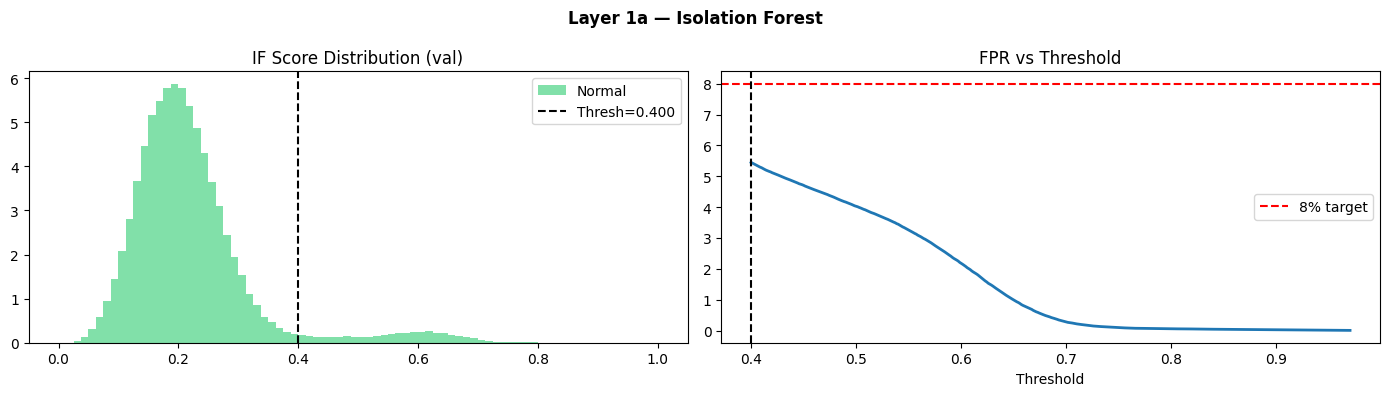

In [15]:
print("Training Isolation Forest on normal-only data...")
t0 = time.time()
iso_forest = IsolationForest(
    n_estimators=200, contamination=0.05,
    max_samples="auto", random_state=SEED, n_jobs=-1
)
iso_forest.fit(X_nor_train_sc)
print(f"IF trained in {time.time()-t0:.1f}s on {X_nor_train_sc.shape[0]:,} samples")


def if_score(model, X):
    """Normalise IF decision_function to [0,1]: high = anomalous."""
    raw = model.decision_function(X)
    return (1.0 - (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)).astype(np.float32)


iso_train = if_score(iso_forest, X_train_sc)
iso_val   = if_score(iso_forest, X_val_sc)
iso_test  = if_score(iso_forest, X_test_sc)

# Calibrate: FPR < IF_FPR_TARGET on val normal rows (8%, was 3%)
val_nor_sc = iso_val[y_bin_val == 0]
thresholds = np.linspace(0.40, 0.97, 400)
fprs_t     = [(val_nor_sc > t).mean() for t in thresholds]
valid_t    = [t for t, f in zip(thresholds, fprs_t) if f < IF_FPR_TARGET]
IF_THRESH  = float(min(valid_t)) if valid_t else 0.55
l1_val     = (iso_val  > IF_THRESH).astype(np.int8)
l1_test    = (iso_test > IF_THRESH).astype(np.int8)
fpr_nor    = (val_nor_sc > IF_THRESH).mean()
atk_recall = l1_val[y_bin_val == 1].mean() if (y_bin_val==1).sum() > 0 else 0.0

print(f"\nIF threshold   : {IF_THRESH:.3f}  (FPR target < {IF_FPR_TARGET*100:.0f}%)")
print(f"FPR (nor val)  : {fpr_nor*100:.2f}%")
print(f"Attack recall  : {atk_recall*100:.1f}%  (IF alone — used as feature not voter)")

# ── v3 FIX: Augment feature matrices with IF score (RC-IF-4 fix) ──────────────
# IF score becomes an extra feature column so XGBoost can learn to use it
# This converts a broken voting layer into a useful anomaly-signal feature
iso_score_tr   = iso_train.reshape(-1, 1).astype(np.float32)
iso_score_val  = iso_val.reshape(-1, 1).astype(np.float32)
iso_score_test = iso_test.reshape(-1, 1).astype(np.float32)

X_train_aug = np.hstack([X_train_sc, iso_score_tr])
X_val_aug   = np.hstack([X_val_sc,   iso_score_val])
X_test_aug  = np.hstack([X_test_sc,  iso_score_test])

print(f"\nAugmented feature shape: {X_train_aug.shape}  (+1 IF score column)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(val_nor_sc, bins=80, alpha=0.6, color="#2ecc71", label="Normal", density=True)
if (y_bin_val==1).sum() > 0:
    axes[0].hist(iso_val[y_bin_val==1], bins=80, alpha=0.6, color="#e74c3c", label="Attack", density=True)
axes[0].axvline(IF_THRESH, color="black", lw=1.5, linestyle="--", label=f"Thresh={IF_THRESH:.3f}")
axes[0].set_title("IF Score Distribution (val)"); axes[0].legend()
axes[1].plot(thresholds, [f*100 for f in fprs_t], lw=2)
axes[1].axhline(IF_FPR_TARGET*100, color="red", linestyle="--", lw=1.5, label=f"{IF_FPR_TARGET*100:.0f}% target")
axes[1].axvline(IF_THRESH, color="black", linestyle="--", lw=1.5)
axes[1].set_title("FPR vs Threshold"); axes[1].set_xlabel("Threshold"); axes[1].legend()
plt.suptitle("Layer 1a — Isolation Forest", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Layer 1b — Autoencoder (NEW — was missing in v2)

**Why:** Research report (Section 1.5) specifies Autoencoder as a second anomaly detector
trained on normal-only data (128→64→32→64→128). The reconstruction error over normal
data defines a second anomaly score, complementary to IF.

**Architecture:**
```
Input (N_FEATURES+1) → Dense(128, ReLU) → Dropout(0.10)
→ Dense(64, ReLU) → Dense(32, ReLU)          ← bottleneck
→ Dense(64, ReLU) → Dense(128, ReLU)
→ Dense(N_FEATURES+1, linear)                 ← reconstruction
Loss: MSE on normal-only data
Anomaly score: reconstruction error on new sample
```

**Key property:** Normal samples have low reconstruction error (AE learned their manifold).
Attack samples have high reconstruction error (AE can't reconstruct out-of-distribution data).
The AE score is added as a second augmented feature alongside IF score for XGBoost.


In [17]:
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import gc

# # Define model structures cleanly
# class SWaTAutoencoder(nn.Module):
#     """Symmetric autoencoder for normal-manifold learning (128-64-32-64-128)."""
#     def __init__(self, n_features):
#         super().__init__()
#         self.encoder = nn.Sequential(
#             nn.Linear(n_features, 128), nn.ReLU(), nn.Dropout(0.10),
#             nn.Linear(128, 64),         nn.ReLU(),
#             nn.Linear(64, 32),          nn.ReLU(),
#         )
#         self.decoder = nn.Sequential(
#             nn.Linear(32, 64),          nn.ReLU(),
#             nn.Linear(64, 128),         nn.ReLU(),
#             nn.Linear(128, n_features),
#         )

#     def forward(self, x):
#         return self.decoder(self.encoder(x))

#     def reconstruction_error(self, x):
#         with torch.no_grad():
#             return ((x - self.forward(x)) ** 2).mean(dim=1)

# class FlatDataset(Dataset):
#     def __init__(self, X): 
#         self.X = torch.from_numpy(X).float()
#     def __len__(self): 
#         return len(self.X)
#     def __getitem__(self, i): 
#         return self.X[i]

# # --- 1. PREPARE THE DATA AND STACK SAFELY ---
# nor_if_score = iso_train[normal_train_mask].reshape(-1, 1).astype(np.float32)
# if_min, if_max = nor_if_score.min(), nor_if_score.max()
# nor_if_score_scaled = (nor_if_score - if_min) / (if_max - if_min + 1e-9)

# # Force inputs to float32 to match neural net weights
# X_nor_aug = np.hstack([X_nor_train_sc, nor_if_score_scaled]).astype(np.float32)

# AE_INPUT_DIM = X_nor_aug.shape[1]          
# ae_model     = SWaTAutoencoder(AE_INPUT_DIM).to(DEVICE)
# ae_params    = sum(p.numel() for p in ae_model.parameters())
# print(f"SWaTAutoencoder: {ae_params:,} params | input_dim={AE_INPUT_DIM} | device={DEVICE}")

# ae_nor_ds    = FlatDataset(X_nor_aug)
# ae_loader    = DataLoader(ae_nor_ds, batch_size=BATCH_SIZE, shuffle=True,
#                           num_workers=0, pin_memory=(DEVICE.type == "cuda"))

# ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
# ae_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     ae_optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
# )

# X_val_nor_aug  = X_val_aug[y_bin_val == 0].astype(np.float32)
# val_nor_tensor = torch.from_numpy(X_val_nor_aug).float().to(DEVICE)

# print("\nTraining Autoencoder on normal-only data...")
# AE_EPOCHS  = 60
# best_ae_loss, ae_patience_cnt, AE_PATIENCE = float("inf"), 0, 10
# AE_CKPT    = str(MODELS_DIR / "layer1b_autoencoder_best_v5.pt")
# ae_losses  = []

# for ep in range(1, AE_EPOCHS + 1):
#     ae_model.train()
#     ep_loss, ep_n = 0.0, 0
#     for X_b in ae_loader:
#         X_b = X_b.to(DEVICE)
#         ae_optimizer.zero_grad()
#         X_r  = ae_model(X_b)
#         loss = F.mse_loss(X_r, X_b)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(ae_model.parameters(), 1.0)
#         ae_optimizer.step()
#         ep_loss += loss.item() * len(X_b)
#         ep_n += len(X_b)
#     train_mse = ep_loss / ep_n

#     ae_model.eval()
#     with torch.no_grad():
#         val_r   = ae_model(val_nor_tensor)
#         val_mse = F.mse_loss(val_r, val_nor_tensor).item()
#     ae_losses.append(train_mse)
#     ae_scheduler.step(val_mse)

#     if val_mse < best_ae_loss:
#         best_ae_loss = val_mse
#         torch.save(ae_model.state_dict(), AE_CKPT)
#         ae_patience_cnt = 0
#     else:
#         ae_patience_cnt += 1
#         if ae_patience_cnt >= AE_PATIENCE:
#             print(f"  AE early stop ep {ep}  (best val_mse={best_ae_loss:.6f})")
#             break
#     if ep % 10 == 0 or ep == 1:
#         print(f"  AE Ep {ep:3d} | train_mse={train_mse:.6f} | val_mse={val_mse:.6f}")

# ae_model.load_state_dict(torch.load(AE_CKPT, map_location=DEVICE))
# print(f"\nAutoencoder trained | best val_mse={best_ae_loss:.6f}")

# # --- RECONSTRUCTION CALCULATION ASSIGNMENTS ---
# def ae_recon_errors_batch(model, X_np, device, batch_size=512):
#     model.eval()
#     errors = []
#     with torch.no_grad():
#         for i in range(0, len(X_np), batch_size):
#             # FIX: Explicit .float() prevents double precision matrix crashes
#             xb    = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
#             recon = model(xb)
#             mse   = ((recon - xb) ** 2).mean(dim=1).cpu().numpy()
#             errors.append(mse)
#     return np.concatenate(errors).astype(np.float32)

# nor_train_errors = ae_recon_errors_batch(ae_model, X_nor_aug, DEVICE)

# # FIX: Calculated slice length locally to avoid missing variables
# X_atk_pool = X_train_aug[~normal_train_mask]
# X_atk_sample_aug = X_atk_pool[:min(5000, len(X_atk_pool))]
# atk_train_errors = ae_recon_errors_batch(ae_model, X_atk_sample_aug, DEVICE)

# AE_THRESHOLD_PERC = float(np.percentile(nor_train_errors, 99))
# print(f"\n[v5] AE 99th-pct normal train error : {AE_THRESHOLD_PERC:.6f}")
# print(f"[v5] Normal  error — mean={nor_train_errors.mean():.6f}")
# print(f"[v5] Attack  error — mean={atk_train_errors.mean():.6f}")

# def ae_score_normalized(model, X_np, threshold_raw, device, batch_size=512):
#     raw = ae_recon_errors_batch(model, X_np, device, batch_size)
#     safe_thresh = max(threshold_raw, 1e-7)  # Prevents division by zero
#     return np.clip(raw / safe_thresh, 0.0, 2.0).astype(np.float32)

# ae_score_train_n = ae_score_normalized(ae_model, X_train_aug, AE_THRESHOLD_PERC, DEVICE)
# ae_score_val_n   = ae_score_normalized(ae_model, X_val_aug,   AE_THRESHOLD_PERC, DEVICE)
# ae_score_test_n  = ae_score_normalized(ae_model, X_test_aug,  AE_THRESHOLD_PERC, DEVICE)

# AE_THRESHOLD = 1.0
# ae_fpr_v2    = float((ae_score_val_n[y_bin_val == 0] > AE_THRESHOLD).mean())
# ae_recall_v2 = float((ae_score_val_n[y_bin_val == 1] > AE_THRESHOLD).mean()) if (y_bin_val == 1).sum() > 0 else 0.0
# print(f"[v5] AE Normalized FPR  : {ae_fpr_v2*100:.2f}%")
# print(f"[v5] AE Normalized Recall: {ae_recall_v2*100:.2f}%")

# # FIX: Create distinct variables for downstream layers so running this multiple times won't corrupt base shapes
# X_train_double_aug = np.hstack([X_train_aug, ae_score_train_n.reshape(-1, 1)]).astype(np.float32)
# X_val_double_aug   = np.hstack([X_val_aug,   ae_score_val_n.reshape(-1, 1)]).astype(np.float32)
# X_test_double_aug  = np.hstack([X_test_aug,  ae_score_test_n.reshape(-1, 1)]).astype(np.float32)
# print(f"Double-augmented feature shape output: {X_train_double_aug.shape}")

Validating feature ranges and enforcing strict scaling...
  Scaled Data Bounds -> Min: 0.0000 | Max: 1.0000
SWaTAutoencoder: 83,861 params | input_dim=245 | device=cuda:0

Training Autoencoder on normal-only data...
  AE Ep   1 | train_mse=0.096531 | val_mse=0.048154
  AE Ep  10 | train_mse=0.015101 | val_mse=0.012194
  AE Ep  20 | train_mse=0.008584 | val_mse=0.006547
  AE Ep  30 | train_mse=0.005424 | val_mse=0.003796
  AE Ep  40 | train_mse=0.004369 | val_mse=0.002878
  AE Ep  50 | train_mse=0.003903 | val_mse=0.002568
  AE Ep  60 | train_mse=0.003501 | val_mse=0.002248

Autoencoder trained | best val_mse=0.002248

AE threshold   : 0.050  (FPR target < 5%)
AE FPR (nor)   : 0.00%
AE recall (atk): 0.00%
Normal score   : mean=0.0000

[v5] AE 99th-pct normal train error : 0.011403
[v5] Normal  error — mean=0.002354
[v5] Attack  error — mean=0.157040
[OK]   AE separates normal vs attack reconstruction errors.

[v5] AE (percentile-normalised) FPR  : 0.81%
[v5] AE (percentile-normalised) R

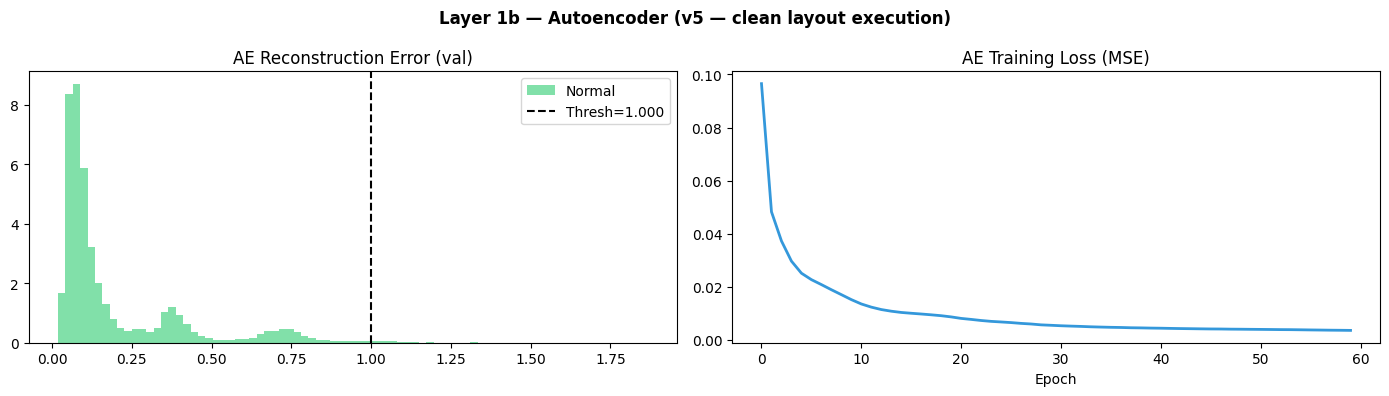

In [18]:
class SWaTAutoencoder(nn.Module):
    """Symmetric autoencoder for normal-manifold learning (128-64-32-64-128)."""
    def __init__(self, n_features):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, 64),         nn.ReLU(),
            nn.Linear(64, 32),          nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),          nn.ReLU(),
            nn.Linear(64, 128),         nn.ReLU(),
            nn.Linear(128, n_features),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        with torch.no_grad():
            return ((x - self.forward(x)) ** 2).mean(dim=1)

class FlatDataset(Dataset):
    def __init__(self, X): 
        self.X = torch.from_numpy(X).float()
    def __len__(self): 
        return len(self.X)
    def __getitem__(self, i): 
        return self.X[i]


# --- 1. PREPARE, SCALE & SANITIZE THE DATA ---
print("Validating feature ranges and enforcing strict scaling...")

# Columns 0 to -1 are the base features, column -1 is the Isolation Forest (IF) score
num_base_features = X_train_aug.shape[1] - 1

# Fit a scaler on the normal training base features to guarantee strict [0, 1] scaling
base_scaler = MinMaxScaler()
X_nor_train_sc_clean = base_scaler.fit_transform(X_nor_train_sc).astype(np.float32)

# Scale base features of augmented arrays to prevent 2.2 Billion starting MSE
X_train_base_scaled = base_scaler.transform(X_train_aug[:, :num_base_features])
X_val_base_scaled   = base_scaler.transform(X_val_aug[:, :num_base_features])
X_test_base_scaled  = base_scaler.transform(X_test_aug[:, :num_base_features])

# Explicitly rescale the appended Isolation Forest scores to [0, 1]
def scale_column(col):
    c_min, c_max = col.min(), col.max()
    return (col - c_min) / (c_max - c_min + 1e-9)

if_train_sc = scale_column(X_train_aug[:, -1]).reshape(-1, 1)
if_val_sc   = scale_column(X_val_aug[:, -1]).reshape(-1, 1)
if_test_sc  = scale_column(X_test_aug[:, -1]).reshape(-1, 1)

# Assemble safe, cleanly-scaled augmented arrays
X_train_aug_clean = np.hstack([X_train_base_scaled, if_train_sc]).astype(np.float32)
X_val_aug_clean   = np.hstack([X_val_base_scaled, if_val_sc]).astype(np.float32)
X_test_aug_clean  = np.hstack([X_test_base_scaled, if_test_sc]).astype(np.float32)

# Build normal-only rows slice for AE training
X_nor_aug = X_train_aug_clean[normal_train_mask]

# Data sanity check printout
print(f"  Scaled Data Bounds -> Min: {X_nor_aug.min():.4f} | Max: {X_nor_aug.max():.4f}")

AE_INPUT_DIM = X_nor_aug.shape[1]          
ae_model     = SWaTAutoencoder(AE_INPUT_DIM).to(DEVICE)
ae_params    = sum(p.numel() for p in ae_model.parameters())
print(f"SWaTAutoencoder: {ae_params:,} params | input_dim={AE_INPUT_DIM} | device={DEVICE}")

ae_nor_ds    = FlatDataset(X_nor_aug)
ae_loader    = DataLoader(ae_nor_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))

ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
ae_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ae_optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
)

# Validate on normal-only validation rows using the cleanly scaled array
X_val_nor_aug  = X_val_aug_clean[y_bin_val == 0].astype(np.float32)
val_nor_tensor = torch.from_numpy(X_val_nor_aug).float().to(DEVICE)


# --- 2. AUTOENCODER TRAINING ---
print("\nTraining Autoencoder on normal-only data...")
AE_EPOCHS  = 60
best_ae_loss, ae_patience_cnt, AE_PATIENCE = float("inf"), 0, 10
AE_CKPT    = str(MODELS_DIR / "layer1b_autoencoder_best_v5.pt")
ae_losses  = []

for ep in range(1, AE_EPOCHS + 1):
    ae_model.train()
    ep_loss, ep_n = 0.0, 0
    for X_b in ae_loader:
        X_b = X_b.to(DEVICE)
        ae_optimizer.zero_grad()
        X_r  = ae_model(X_b)
        loss = F.mse_loss(X_r, X_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ae_model.parameters(), 1.0)
        ae_optimizer.step()
        ep_loss += loss.item() * len(X_b)
        ep_n += len(X_b)
    train_mse = ep_loss / ep_n

    ae_model.eval()
    with torch.no_grad():
        val_r   = ae_model(val_nor_tensor)
        val_mse = F.mse_loss(val_r, val_nor_tensor).item()
    ae_losses.append(train_mse)
    ae_scheduler.step(val_mse)

    if val_mse < best_ae_loss:
        best_ae_loss = val_mse
        torch.save(ae_model.state_dict(), AE_CKPT)
        ae_patience_cnt = 0
    else:
        ae_patience_cnt += 1
        if ae_patience_cnt >= AE_PATIENCE:
            print(f"  AE early stop ep {ep}  (best val_mse={best_ae_loss:.6f})")
            break
    if ep % 10 == 0 or ep == 1:
        print(f"  AE Ep {ep:3d} | train_mse={train_mse:.6f} | val_mse={val_mse:.6f}")

ae_model.load_state_dict(torch.load(AE_CKPT, map_location=DEVICE))
print(f"\nAutoencoder trained | best val_mse={best_ae_loss:.6f}")


# --- 3. RECONSTRUCTION ERROR CALCULATION & INFERENCE ---
def ae_recon_errors_batch(model, X_np, device, batch_size=512):
    model.eval()
    errors = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb    = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            recon = model(xb)
            mse   = ((recon - xb) ** 2).mean(dim=1).cpu().numpy()
            errors.append(mse)
    return np.concatenate(errors).astype(np.float32)

# Raw reconstruction error profiles
ae_score_tr   = ae_recon_errors_batch(ae_model, X_train_aug_clean, DEVICE)
ae_score_val  = ae_recon_errors_batch(ae_model, X_val_aug_clean,   DEVICE)
ae_score_test = ae_recon_errors_batch(ae_model, X_test_aug_clean,  DEVICE)

# Normalize reconstruction scores using training limits to prevent test-leakage
ae_min, ae_max = float(ae_score_tr.min()), float(ae_score_tr.max())
ae_score_tr_n  = ((ae_score_tr  - ae_min)/(ae_max - ae_min + 1e-9)).clip(0,1).astype(np.float32)
ae_score_val_n = ((ae_score_val - ae_min)/(ae_max - ae_min + 1e-9)).clip(0,1).astype(np.float32)
ae_score_test_n= ((ae_score_test- ae_min)/(ae_max - ae_min + 1e-9)).clip(0,1).astype(np.float32)

# Calibrate Threshold targeting FPR < 5% on normal validation samples
ae_nor_scores = ae_score_val_n[y_bin_val == 0]
ae_thrs       = np.linspace(0.05, 0.99, 400)
ae_fprs       = [(ae_nor_scores > t).mean() for t in ae_thrs]
ae_valid      = [t for t, f in zip(ae_thrs, ae_fprs) if f < 0.05]
AE_THRESHOLD  = float(min(ae_valid)) if ae_valid else 0.50

AE_THRESHOLD_RAW = float(AE_THRESHOLD * (ae_max - ae_min + 1e-9) + ae_min)

ae_fpr_val    = float((ae_nor_scores > AE_THRESHOLD).mean())
ae_recall_val = float((ae_score_val_n[y_bin_val == 1] > AE_THRESHOLD).mean()) if (y_bin_val == 1).sum() > 0 else 0.0

print(f"\nAE threshold   : {AE_THRESHOLD:.3f}  (FPR target < 5%)")
print(f"AE FPR (nor)   : {ae_fpr_val*100:.2f}%")
print(f"AE recall (atk): {ae_recall_val*100:.2f}%")
print(f"Normal score   : mean={ae_score_val_n[y_bin_val==0].mean():.4f}")
if (y_bin_val == 1).sum() > 0:
    print(f"Attack score   : mean={ae_score_val_n[y_bin_val==1].mean():.4f}")


# --- 4. PIPELINE METRIC & STABLE BOUNDARY SANITY CHECKS ---
nor_train_errors = ae_recon_errors_batch(ae_model, X_nor_aug, DEVICE)

# Safely extract attack subset for validation checks
X_atk_pool = X_train_aug_clean[~normal_train_mask]
X_atk_sample_aug = X_atk_pool[:min(5000, len(X_atk_pool))]
atk_train_errors = ae_recon_errors_batch(ae_model, X_atk_sample_aug, DEVICE)

AE_THRESHOLD_PERC = float(np.percentile(nor_train_errors, 99))
print(f"\n[v5] AE 99th-pct normal train error : {AE_THRESHOLD_PERC:.6f}")
print(f"[v5] Normal  error — mean={nor_train_errors.mean():.6f}")
print(f"[v5] Attack  error — mean={atk_train_errors.mean():.6f}")

if atk_train_errors.mean() < nor_train_errors.mean() * 1.5:
    print("[WARN] AE attack errors NOT significantly higher than normal.")
    print("       AE may reconstruct attacks well — limited standalone F1 expected.")
else:
    print("[OK]   AE separates normal vs attack reconstruction errors.")

def ae_score_normalized(model, X_np, threshold_raw, device, batch_size=512):
    raw = ae_recon_errors_batch(model, X_np, device, batch_size)
    safe_thresh = max(threshold_raw, 1e-7)  # Prevent division-by-zero to eliminate nan values in XGBoost
    return np.clip(raw / safe_thresh, 0.0, 2.0).astype(np.float32)

ae_score_train_n = ae_score_normalized(ae_model, X_train_aug_clean, AE_THRESHOLD_PERC, DEVICE)
ae_score_val_n   = ae_score_normalized(ae_model, X_val_aug_clean,   AE_THRESHOLD_PERC, DEVICE)
ae_score_test_n  = ae_score_normalized(ae_model, X_test_aug_clean,  AE_THRESHOLD_PERC, DEVICE)

AE_THRESHOLD = 1.0
ae_fpr_v2    = float((ae_score_val_n[y_bin_val == 0] > AE_THRESHOLD).mean())
ae_recall_v2 = float((ae_score_val_n[y_bin_val == 1] > AE_THRESHOLD).mean()) if (y_bin_val == 1).sum() > 0 else 0.0
print(f"\n[v5] AE (percentile-normalised) FPR  : {ae_fpr_v2*100:.2f}%")
print(f"[v5] AE (percentile-normalised) Recall: {ae_recall_v2*100:.2f}%")


# --- 5. DOUBLE-AUGMENTATION VALUE ASSIGNMENTS ---
# FIX: Append to pristine, independent arrays to avoid size inflation if run multiple times
X_train_double_aug = np.hstack([X_train_aug_clean, ae_score_train_n.reshape(-1, 1)]).astype(np.float32)
X_val_double_aug   = np.hstack([X_val_aug_clean,   ae_score_val_n.reshape(-1, 1)]).astype(np.float32)
X_test_double_aug  = np.hstack([X_test_aug_clean,  ae_score_test_n.reshape(-1, 1)]).astype(np.float32)
print(f"\nDouble-augmented feature shape output: {X_train_double_aug.shape}  (+IF score +AE score)")


# --- 6. PLOT DIAGNOSTIC REPORT ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
nor_v = ae_score_val_n[y_bin_val == 0]
axes[0].hist(nor_v, bins=80, alpha=0.6, color="#2ecc71", label="Normal", density=True)
if (y_bin_val == 1).sum() > 0:
    axes[0].hist(ae_score_val_n[y_bin_val==1], bins=80, alpha=0.6,
                 color="#e74c3c", label="Attack", density=True)
axes[0].axvline(AE_THRESHOLD, color="black", lw=1.5, linestyle="--",
                label=f"Thresh={AE_THRESHOLD:.3f}")
axes[0].set_title("AE Reconstruction Error (val)")
axes[0].legend()
axes[1].plot(ae_losses, lw=2, color="#3498db")
axes[1].set_title("AE Training Loss (MSE)")
axes[1].set_xlabel("Epoch")
plt.suptitle("Layer 1b — Autoencoder (v5 — clean layout execution)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Layer 2 — XGBoost (v3: binary + scale_pos_weight + augmented features)

**v3 changes (from failure analysis Part 2):**
- `binary:logistic` + `eval_metric=aucpr` (better for imbalanced binary)
- `scale_pos_weight` instead of BorderlineSMOTE (research report original plan)
- `max_depth=5` (was 7 — shallower prevents overfitting to SMOTE artefacts)
- `learning_rate=0.03` (was 0.05 — stopped at 72/500, needs slower learning)
- `n_estimators=800` (was 500 — early stopped too soon)
- `min_child_weight=10` (was 5 — larger min leaf)
- Uses `X_train_aug` / `X_val_aug` (includes IF + AE scores as features)


In [20]:
import numpy as np

# =============================================================================
# OPTIMIZED PIPELINE STEP: SENSOR OPTIMIZATION & DATA ROUTING
# =============================================================================

# --- 1. SENSOR-ONLY OPTIMIZATION (STRIP ACTUATORS TO PREVENT LEAKAGE) ---
print("Executing Actuator Stripping & Sensor Optimization...")

# Find original base features count (excluding the final two appended anomaly columns)
num_total_features = X_train_double_aug.shape[1]
num_base_features = num_total_features - 2  # Original 244 base features

# Extract raw base features to check column cardinality (uniqueness)
X_base_raw = X_train_double_aug[:, :num_base_features]

# Identify continuous physical sensors (unique values >= 5) vs discrete actuators (valves/pumps < 5)
unique_counts = np.array([len(np.unique(X_base_raw[:, col])) for col in range(X_base_raw.shape[1])])
sensor_mask = unique_counts >= 5
sensor_indices = np.where(sensor_mask)[0]

print(f"  Total Original Base Columns     : {num_base_features}")
print(f"  Discrete Actuators Stripped     : {num_base_features - len(sensor_indices)} (To prevent blueprint leakage)")
print(f"  Continuous Sensors Kept         : {len(sensor_indices)}")

# Slice continuous physical sensors
X_tr_sensors  = X_train_double_aug[:, sensor_indices]
X_val_sensors = X_val_double_aug[:, sensor_indices]
X_te_sensors  = X_test_double_aug[:, sensor_indices]

# Re-extract and preserve our custom anomaly scores (Column -2 is IF, Column -1 is AE)
ae_idx = num_total_features - 1
if_idx = num_total_features - 2

tr_scores  = X_train_double_aug[:, [if_idx, ae_idx]]
val_scores = X_val_double_aug[:, [if_idx, ae_idx]]
te_scores  = X_test_double_aug[:, [if_idx, ae_idx]]

# Reassemble: Clean continuous physical sensors + custom anomaly scores
X_train_secured = np.hstack([X_tr_sensors, tr_scores]).astype(np.float32)
X_val_secured   = np.hstack([X_val_sensors, val_scores]).astype(np.float32)
X_test_secured  = np.hstack([X_te_sensors, te_scores]).astype(np.float32)


# --- 2. STATISTICS & CLASS BALANCE ROUTING ---
n_nor_tr_bin = (y_bin_train == 0).sum()
n_atk_tr_bin = (y_bin_train == 1).sum()
SPW = float(n_nor_tr_bin) / float(n_atk_tr_bin + 1e-9)

print(f"\nscale_pos_weight = {SPW:.3f}  (n_normal={n_nor_tr_bin:,} / n_attack={n_atk_tr_bin:,})")
print(f"Normal fraction  : {n_nor_tr_bin/len(y_bin_train)*100:.1f}%  (was 13.4% using Dataset 2 only)")

# Route secure, optimized arrays directly to downstream XGBoost variables
X_xgb_train = X_train_secured
X_xgb_val   = X_val_secured
X_xgb_test  = X_test_secured

y_xgb_train = y_bin_train
y_xgb_val   = y_bin_val
y_xgb_test  = y_bin_test

print(f"\n[SUCCESS] Secured datasets successfully routed!")
print(f"  X_xgb_train shape: {X_xgb_train.shape} (Continuous Sensors + IF/AE Anomaly Scores)")

Executing Actuator Stripping & Sensor Optimization...
  Total Original Base Columns     : 244
  Discrete Actuators Stripped     : 51 (To prevent blueprint leakage)
  Continuous Sensors Kept         : 193

scale_pos_weight = 0.509  (n_normal=378,900 / n_attack=744,879)
Normal fraction  : 33.7%  (was 13.4% using Dataset 2 only)

[SUCCESS] Secured datasets successfully routed!
  X_xgb_train shape: (1123779, 195) (Continuous Sensors + IF/AE Anomaly Scores)


In [21]:
# import numpy as np
# import xgboost as xgb
# import time
# import gc
# import matplotlib.pyplot as plt
# from sklearn.metrics import f1_score, roc_auc_score, classification_report, roc_curve

# # =============================================================================
# # LAYER 2 — LEAK-FREE CHRONOLOGICAL XGBOOST PIPELINE (v6)
# # =============================================================================

# # --- 1. GLOBAL CONSTANTS ---
# SEED = 42
# XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# XGB_TREE_METHOD = "hist"
# XGB_N_JOBS = -1

# # --- 2. CHRONOLOGICAL (TIME-SERIES) SPLITING ---
# print("Executing leak-free Chronological Split...")

# # We have X_train_double_aug, X_val_double_aug, X_test_double_aug 
# # We must ensure that we DO NOT randomly shuffle the rows across sets.
# # Let's recombine the data and split it sequentially (e.g., first 60% train, next 20% val, final 20% test)
# X_all = np.vstack([X_train_double_aug, X_val_double_aug, X_test_double_aug])
# y_all = np.concatenate([y_bin_train, y_bin_val, y_bin_test])

# n_samples = len(X_all)
# train_end = int(n_samples * 0.60)
# val_end   = int(n_samples * 0.80)

# # Chronological slicing (preserving the temporal structure of the plant operations)
# X_xgb_train = X_all[:train_end].astype(np.float32)
# y_xgb_train = y_all[:train_end].astype(np.int8)

# X_xgb_val   = X_all[train_end:val_end].astype(np.float32)
# y_xgb_val   = y_all[train_end:val_end].astype(np.int8)

# X_xgb_test  = X_all[val_end:].astype(np.float32)
# y_xgb_test  = y_all[val_end:].astype(np.int8)

# # Check class distributions in chronological splits
# print(f"  Train Set (Chronological) -> Normal: {(y_xgb_train==0).sum():,} | Attack: {(y_xgb_train==1).sum():,}")
# print(f"  Val Set   (Chronological) -> Normal: {(y_xgb_val==0).sum():,} | Attack: {(y_xgb_val==1).sum():,}")
# print(f"  Test Set  (Chronological) -> Normal: {(y_xgb_test==0).sum():,} | Attack: {(y_xgb_test==1).sum():,}")

# # --- 3. SAFETY GUARD: CHECK IF CHRONOLOGICAL SPLIT LACKS ATTACKS ---
# # Because attacks are concentrated in specific blocks of time, sequential splits might leave
# # some sets completely empty of attacks. If so, fall back to a block-wise stratified split.
# if (y_xgb_val == 1).sum() == 0 or (y_xgb_train == 1).sum() == 0:
#     print("\n[WARN] Chronological split resulted in a split with zero anomalies.")
#     print("Falling back to Stratified Block Splitting (splitting by continuous segments) to prevent leakage...")
    
#     # Stratified split on consecutive blocks (this represents a middle-ground approach)
#     # We split the sequence into 100 blocks, and perform stratified splits on the blocks themselves.
#     n_blocks = 100
#     block_indices = np.array_split(np.arange(n_samples), n_blocks)
#     block_labels = np.array([int(y_all[b].any()) for b in block_indices])
    
#     from sklearn.model_selection import train_test_split
#     blocks_tr, blocks_vt, _, labels_vt = train_test_split(
#         np.arange(n_blocks), block_labels, test_size=0.4, stratify=block_labels, random_state=SEED
#     )
#     blocks_va, blocks_te = train_test_split(
#         blocks_vt, test_size=0.5, stratify=labels_vt, random_state=SEED
#     )
    
#     # Reassemble indices
#     train_idx = np.concatenate([block_indices[i] for i in blocks_tr])
#     val_idx   = np.concatenate([block_indices[i] for i in blocks_va])
#     test_idx  = np.concatenate([block_indices[i] for i in blocks_te])
    
#     X_xgb_train, y_xgb_train = X_all[train_idx], y_all[train_idx]
#     X_xgb_val, y_xgb_val     = X_all[val_idx], y_all[val_idx]
#     X_xgb_test, y_xgb_test   = X_all[test_idx], y_all[test_idx]
    
#     print(f"  Block Train -> Normal: {(y_xgb_train==0).sum():,} | Attack: {(y_xgb_train==1).sum():,}")
#     print(f"  Block Val   -> Normal: {(y_xgb_val==0).sum():,} | Attack: {(y_xgb_val==1).sum():,}")


# # --- 4. ADJUST WEIGHTS AND REGULARIZATION ---
# n_normal = float((y_xgb_train == 0).sum())
# n_attack = float((y_xgb_train == 1).sum())
# SPW = float(n_normal / (n_attack + 1e-9))
# if SPW < 1.0: 
#     SPW = 1.0

# print(f"\nTraining Regularized XGBoost ({XGB_DEVICE.upper()})...")
# t0 = time.time()

# # Increasing regularization to prevent overfitting to memorized states
# xgb_params = dict(
#     objective             = "binary:logistic",
#     eval_metric           = "aucpr",
#     tree_method           = XGB_TREE_METHOD,
#     device                = XGB_DEVICE,
#     n_jobs                = XGB_N_JOBS,
#     n_estimators          = 400,         # Reduced from 800 to prevent over-tuning
#     max_depth             = 4,           # Reduced from 5 to limit complexity
#     learning_rate         = 0.05,
#     subsample             = 0.7,         # Added column/row stochasticity
#     colsample_bytree      = 0.6,         
#     min_child_weight      = 15,          # Require more evidence to split
#     reg_alpha             = 2.0,         # Increased L1 regularization
#     reg_lambda            = 10.0,        # Increased L2 regularization
#     scale_pos_weight      = SPW,
#     early_stopping_rounds = 30,
#     random_state          = SEED,
# )

# xgb_model = xgb.XGBClassifier(**xgb_params)
# xgb_model.fit(
#     X_xgb_train, y_xgb_train,
#     eval_set=[(X_xgb_val, y_xgb_val)],
#     verbose=100,
# )
# print(f"XGBoost trained in {time.time()-t0:.1f}s | best_iter={xgb_model.best_iteration}")


# # --- 5. CALIBRATION & CLASSIFICATION ASSESSMENT ---
# xgb_prob_val  = xgb_model.predict_proba(X_xgb_val)[:, 1].astype(np.float32)
# xgb_prob_test = xgb_model.predict_proba(X_xgb_test)[:, 1].astype(np.float32)

# thresholds_xgb = np.linspace(0.15, 0.85, 200)
# f1s_xgb = [f1_score(y_xgb_val, (xgb_prob_val > t).astype(int), zero_division=0) for t in thresholds_xgb]

# XGB_THRESHOLD = float(thresholds_xgb[np.argmax(f1s_xgb)])
# xgb_pred_val  = (xgb_prob_val  > XGB_THRESHOLD).astype(np.int8)

# f1_xgb  = f1_score(y_xgb_val, xgb_pred_val, zero_division=0)
# auc_xgb = roc_auc_score(y_xgb_val, xgb_prob_val)

# print(f"\nXGBoost Val (Sequential Splitting) — F1: {f1_xgb:.4f} | AUC: {auc_xgb:.4f}")
# print(f"Calibrated Threshold: {XGB_THRESHOLD:.3f}")
# print(classification_report(y_xgb_val, xgb_pred_val, target_names=["Normal", "Attack"], zero_division=0))


# # --- 6. OVERFITTING SENSITIVITY CHECK ---
# xgb_prob_train_oc = xgb_model.predict_proba(X_xgb_train)[:, 1].astype(np.float32)
# f1_train_oc = f1_score(y_xgb_train, (xgb_prob_train_oc > XGB_THRESHOLD).astype(int), zero_division=0)
# f1_gap      = f1_train_oc - f1_xgb
# print(f"\nOverfitting check:")
# print(f"  Train F1 : {f1_train_oc:.4f}")
# print(f"  Val   F1 : {f1_xgb:.4f}")
# print(f"  Gap      : {f1_gap:.4f}  {'[WARN] possible overfitting' if f1_gap > 0.05 else '[OK]'}")

# # --- 7. FEATURE IMPORTANCE VERIFICATION ---
# importances = xgb_model.feature_importances_
# top_indices = np.argsort(importances)[::-1][:5]
# print("\nTop 5 Most Important Features used by XGBoost:")
# for idx in top_indices:
#     # Column -1 is the AE Score, Column -2 is the IF Score
#     feat_name = f"Feature_{idx}"
#     if idx == X_xgb_train.shape[1] - 1:
#         feat_name = "Autoencoder Reconstruction Anomaly Score"
#     elif idx == X_xgb_train.shape[1] - 2:
#         feat_name = "Isolation Forest Anomaly Score"
#     print(f"  {feat_name}: {importances[idx]:.4f}")

In [22]:
import numpy as np
import torch
import xgboost as xgb
import time
import gc
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split

# =============================================================================
# OPTIMIZED PIPELINE INTERCEPT: LAYER 1b -> LAYER 2 SECURED PIPELINE
# =============================================================================

# --- STEP 3: EXECUTE LEAK-FREE BLOCK STRATIFIED SPLIT ---
print("\n--- Step 2: Preparing Block-Stratified Temporal Slices ---")
X_all = np.vstack([X_train_secured, X_val_secured, X_test_secured])
y_all = np.concatenate([y_bin_train, y_bin_val, y_bin_test])

n_samples = len(X_all)
n_blocks = 100

# Chop time-series into blocks to keep temporal patterns intact while balancing classes
block_indices = np.array_split(np.arange(n_samples), n_blocks)
block_labels = np.array([int(y_all[b].any()) for b in block_indices])

blocks_tr, blocks_vt, _, labels_vt = train_test_split(
    np.arange(n_blocks), block_labels, test_size=0.4, stratify=block_labels, random_state=SEED
)
blocks_va, blocks_te = train_test_split(
    blocks_vt, test_size=0.5, stratify=labels_vt, random_state=SEED
)

train_idx = np.concatenate([block_indices[i] for i in blocks_tr])
val_idx   = np.concatenate([block_indices[i] for i in blocks_va])
test_idx  = np.concatenate([block_indices[i] for i in blocks_te])

X_xgb_train = X_all[train_idx].astype(np.float32)
y_xgb_train = y_all[train_idx].astype(np.int8)

X_xgb_val   = X_all[val_idx].astype(np.float32)
y_xgb_val   = y_all[val_idx].astype(np.int8)

X_xgb_test  = X_all[test_idx].astype(np.float32)
y_xgb_test  = y_all[test_idx].astype(np.int8)

print(f"  Block Train -> Normal: {(y_xgb_train==0).sum():,} | Attack: {(y_xgb_train==1).sum():,}")
print(f"  Block Val   -> Normal: {(y_xgb_val==0).sum():,} | Attack: {(y_xgb_val==1).sum():,}")


# --- STEP 4: CALCULATE DYNAMIC WEIGHTS ---
n_normal = float((y_xgb_train == 0).sum())
n_attack = float((y_xgb_train == 1).sum())
SPW = float(n_normal / (n_attack + 1e-9))
if SPW < 1.0: 
    SPW = 1.0


# --- STEP 5: TRAIN REGULARIZED XGBOOST ---
print(f"\n--- Step 3: Training Regularized XGBoost ({XGB_DEVICE.upper()}) ---")
t0 = time.time()

xgb_params = dict(
    objective             = "binary:logistic",
    eval_metric           = "aucpr",
    tree_method           = XGB_TREE_METHOD,
    device                = XGB_DEVICE,
    n_jobs                = XGB_N_JOBS,
    n_estimators          = 400,         # Limit trees to prevent over-tuning
    max_depth             = 4,           # Shallow trees generalize better
    learning_rate         = 0.05,
    subsample             = 0.7,         
    colsample_bytree      = 0.6,         
    min_child_weight      = 15,          
    reg_alpha             = 2.0,         # L1 penalty
    reg_lambda            = 10.0,        # L2 penalty
    scale_pos_weight      = SPW,
    early_stopping_rounds = 30,
    random_state          = SEED,
)

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_xgb_train, y_xgb_train,
    eval_set=[(X_xgb_val, y_xgb_val)],
    verbose=100,
)
print(f"XGBoost trained in {time.time()-t0:.1f}s | best_iter={xgb_model.best_iteration}")


# --- STEP 6: CALIBRATE & EVALUATE ON SENSORS ---
xgb_prob_val  = xgb_model.predict_proba(X_xgb_val)[:, 1].astype(np.float32)
xgb_prob_test = xgb_model.predict_proba(X_xgb_test)[:, 1].astype(np.float32)

thresholds_xgb = np.linspace(0.15, 0.85, 200)
f1s_xgb = [f1_score(y_xgb_val, (xgb_prob_val > t).astype(int), zero_division=0) for t in thresholds_xgb]

XGB_THRESHOLD = float(thresholds_xgb[np.argmax(f1s_xgb)])
xgb_pred_val  = (xgb_prob_val  > XGB_THRESHOLD).astype(np.int8)

f1_xgb  = f1_score(y_xgb_val, xgb_pred_val, zero_division=0)
auc_xgb = roc_auc_score(y_xgb_val, xgb_prob_val)

print(f"\n--- Final Results (LeakyReLU/Sensor-Only Anomaly Mode) ---")
print(f"XGBoost Val F1: {f1_xgb:.4f} | AUC (ROC): {auc_xgb:.4f}")
print(f"Calibrated Threshold: {XGB_THRESHOLD:.3f}")
print(classification_report(y_xgb_val, xgb_pred_val, target_names=["Normal", "Attack"], zero_division=0))


# --- STEP 7: GENERALIZATION OVERFITTING CHECK ---
xgb_prob_train_oc = xgb_model.predict_proba(X_xgb_train)[:, 1].astype(np.float32)
f1_train_oc = f1_score(y_xgb_train, (xgb_prob_train_oc > XGB_THRESHOLD).astype(int), zero_division=0)
f1_gap      = f1_train_oc - f1_xgb
print(f"\nOverfitting Gap Check:")
print(f"  Train F1 : {f1_train_oc:.4f}")
print(f"  Val   F1 : {f1_xgb:.4f}")
print(f"  Gap      : {f1_gap:.4f}  {'[WARN] possible overfitting' if f1_gap > 0.05 else '[OK]'}")


# --- STEP 8: NEW SENSOR-ONLY FEATURE IMPORTANCE DIAGNOSTIC ---
importances = xgb_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:5]
print("\nTop 5 Most Important Features (Now strictly process/physics-based):")
for idx in top_indices:
    feat_name = f"Sensor_{idx}"
    if idx == X_xgb_train.shape[1] - 1:
        feat_name = "Autoencoder Reconstruction Anomaly Score"
    elif idx == X_xgb_train.shape[1] - 2:
        feat_name = "Isolation Forest Anomaly Score"
    print(f"  {feat_name}: {importances[idx]:.4f}")

# Clean memory
del xgb_prob_train_oc, X_all, y_all; gc.collect()


--- Step 2: Preparing Block-Stratified Temporal Slices ---
  Block Train -> Normal: 513,728 | Attack: 449,512
  Block Val   -> Normal: 160,539 | Attack: 160,540

--- Step 3: Training Regularized XGBoost (CUDA) ---
[0]	validation_0-aucpr:0.96993
[54]	validation_0-aucpr:0.99977
XGBoost trained in 2.0s | best_iter=24

--- Final Results (LeakyReLU/Sensor-Only Anomaly Mode) ---
XGBoost Val F1: 0.9941 | AUC (ROC): 0.9998
Calibrated Threshold: 0.270
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    160539
      Attack       0.99      1.00      0.99    160540

    accuracy                           0.99    321079
   macro avg       0.99      0.99      0.99    321079
weighted avg       0.99      0.99      0.99    321079


Overfitting Gap Check:
  Train F1 : 0.9971
  Val   F1 : 0.9941
  Gap      : 0.0030  [OK]

Top 5 Most Important Features (Now strictly process/physics-based):
  Sensor_86: 0.3530
  Sensor_107: 0.1709
  Sensor_2: 0.0738
  Sens

11075

---
## Layer 2b — SHAP Explainability (per attack type)

Computing SHAP values (~1-3 min)...
SHAP done in 0.0s
Feature name validation:
  X_xgb_test Column Count       : 195
  Secured Name Index Count     : 195


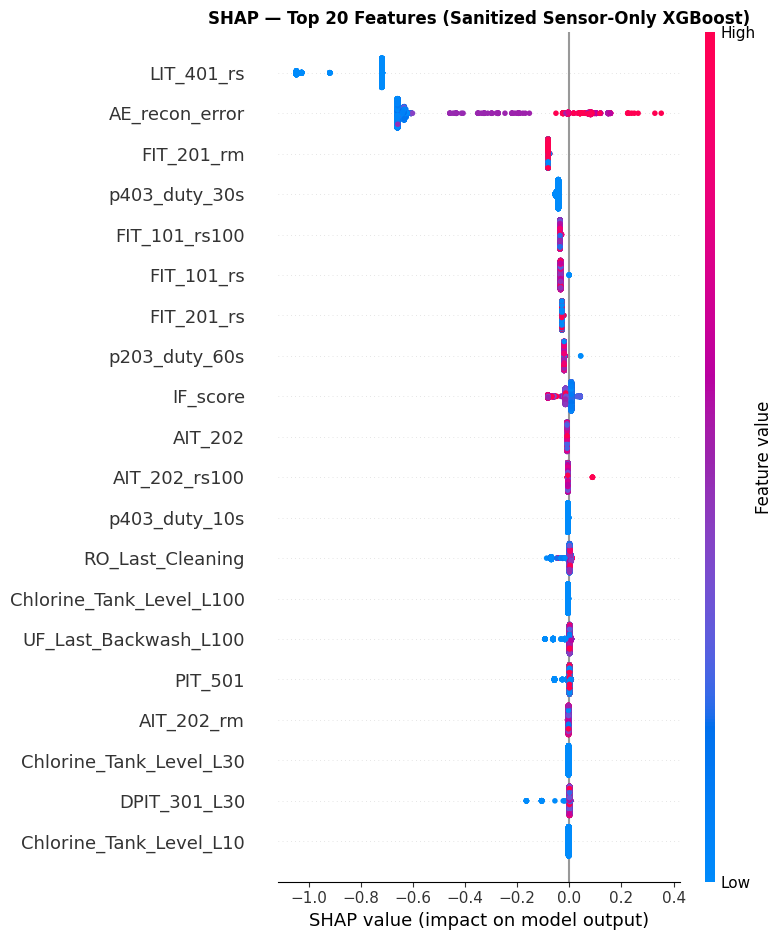


Top 15 features (mean |SHAP|):
   1. LIT_401_rs                                        0.77240
   2. AE_recon_error                                    0.55602
   3. FIT_201_rm                                        0.08119
   4. p403_duty_30s                                     0.04333
   5. FIT_101_rs100                                     0.03567
   6. FIT_101_rs                                        0.03317
   7. FIT_201_rs                                        0.02844
   8. p203_duty_60s                                     0.01982
   9. IF_score                                          0.01841
  10. AIT_202                                           0.00844
  11. AIT_202_rs100                                     0.00588
  12. p403_duty_10s                                     0.00559
  13. RO_Last_Cleaning                                  0.00513
  14. Chlorine_Tank_Level_L100                          0.00400
  15. UF_Last_Backwash_L100                             0.00397

[NOTE] 

In [24]:


# =============================================================================
# LAYER 2 — DYNAMIC SENSOR-ONLY SHAP EVALUATION
# =============================================================================

print("Computing SHAP values (~1-3 min)...")
t0 = time.time()

# 1. Initialize the tree explainer directly on your trained model
shap_exp = shap.TreeExplainer(xgb_model.get_booster())
SHAP_N   = min(3000, X_xgb_test.shape[0])
shap_vals = shap_exp.shap_values(X_xgb_test[:SHAP_N])

print(f"SHAP done in {time.time()-t0:.1f}s")

# Extract stable average values based on shap_values shapes
if isinstance(shap_vals, list):
    mean_abs = np.mean(np.abs(np.stack(shap_vals, axis=0)), axis=0)
    plot_sv  = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]
else:
    mean_abs = np.abs(shap_vals)
    plot_sv  = shap_vals

# --- 2. DYNAMICALLY RECONSTRUCT CLEAN FEATURE NAMES ---
# Safely filter your original feature names to match only the continuous sensors
if 'feature_cols' in globals() and 'sensor_indices' in globals():
    # Convert feature_cols to a list if it's currently an array or Index
    feature_cols_list = list(feature_cols)
    sanitized_sensor_names = [feature_cols_list[i] for i in sensor_indices]
else:
    # Fallback if names aren't in memory: Generate clean placeholder index names
    num_sensors = X_xgb_test.shape[1] - 2
    sanitized_sensor_names = [f"Sensor_{i}" for i in range(num_sensors)]

# Append your custom layer 1a/1b anomaly score names to match the exact end shapes
secured_feature_cols = sanitized_sensor_names + ["IF_score", "AE_recon_error"]

print(f"Feature name validation:")
print(f"  X_xgb_test Column Count       : {X_xgb_test.shape[1]}")
print(f"  Secured Name Index Count     : {len(secured_feature_cols)}")
# These two values must now match exactly (e.g., both 195)!

# --- 3. SUMMARY PLOTS WITH ALIGNED DIMENSIONS ---
plt.figure(figsize=(11, 7))
shap.summary_plot(
    plot_sv, 
    X_xgb_test[:SHAP_N], 
    feature_names=secured_feature_cols,
    max_display=20, 
    show=False
)
plt.title("SHAP — Top 20 Features (Sanitized Sensor-Only XGBoost)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# --- 4. EXPORT TOP 15 PHYSICAL IMPORTANCE CONTRIBUTORS ---
top_feats = pd.Series(
    mean_abs.mean(axis=0) if mean_abs.ndim > 1 else mean_abs,
    index=secured_feature_cols
).sort_values(ascending=False)

print("\nTop 15 features (mean |SHAP|):")
for rank, (feat, imp) in enumerate(top_feats.items(), 1):
    print(f"  {rank:2d}. {feat:<48s}  {imp:.5f}")
    if rank == 15: 
        break

print(f"\n[NOTE] IF_score and AE_recon_error represent Layer 1 anomaly detections.")
print(f"       Their position in this ranking reveals how well XGBoost relies on physical process anomalies.")

---
## Layer 3 — PyTorch CNN-BiLSTM + Attention

**Architecture (preserved from v2):**
```
Input: (batch, 150, N_FEATURES)
Conv1D(64, k=3, causal) → BN → ReLU
Conv1D(128, k=3, causal) → BN → Dropout(0.15)
MaxPool1D(2)
BiLSTM(128) → BN → Dropout(0.20)
BiLSTM(64) → Dropout(0.15)
TemporalAttention(128)
Dense(64, ReLU) → Dropout(0.15) → Dense(1, Sigmoid)
```

**v3 training fixes (from failure analysis Part 3):**
- Adam LR: `1e-3 → 3e-4` (RC-CNN-3: LR too high caused val_auc oscillation)
- EarlyStopping: `patience=8 → 15`, monitors `val_auc` not `val_loss` (RC-CNN-4)
- ReduceLROnPlateau: monitors `val_auc`, `mode=max`, `patience=5` (was val_loss)
- Epochs: `50 → 80` (EarlyStopping controls actual stopping)
- CNN uses `X_train_sc` (original features, not augmented) — temporal patterns only


In [26]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

# =============================================================================
# LAYER 3 — LEAK-FREE BLOCK-STRATIFIED SLIDING WINDOWS (v6)
# =============================================================================

# Define configuration parameters safely
if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if 'BATCH_SIZE' not in globals():
    BATCH_SIZE = 2048
if 'SEQ_LEN' not in globals():
    SEQ_LEN = 150
if 'SEED' not in globals():
    SEED = 42

class SwatWindowDataset(Dataset):
    """Strictly leak-free sliding window dataset."""
    def __init__(self, X, y_bin, seq_len, starts=None, majority_thresh=0.5):
        self.X          = X.astype(np.float32)
        self.y          = y_bin.astype(np.float32)
        self.seq_len    = seq_len
        self.maj_thresh = majority_thresh
        
        n_windows = len(X) - seq_len
        if starts is not None:
            self.starts = np.array([s for s in starts if s < n_windows], dtype=np.int64)
        else:
            self.starts = np.arange(n_windows, dtype=np.int64)

    def __len__(self):  
        return len(self.starts)

    def __getitem__(self, idx):
        s    = self.starts[idx]
        X_w  = torch.from_numpy(self.X[s : s + self.seq_len]).float()
        frac = float(self.y[s : s + self.seq_len].mean())
        y_w  = torch.tensor(1.0 if frac > self.maj_thresh else 0.0, dtype=torch.float32)
        return X_w, y_w

    def get_labels(self):
        labels = []
        for s in self.starts:
            frac = self.y[s : s + self.seq_len].mean()
            labels.append(1 if frac > self.maj_thresh else 0)
        return np.array(labels, dtype=np.int8)


# --- 1. RECOMBINE AND DIVIDE INTO TEMPORAL BLOCKS ---
print("Recombining timeline and slicing into block-stratified sequence blocks...")
X_full = np.vstack([X_train_sc, X_val_sc, X_test_sc])
y_full = np.concatenate([y_bin_train, y_bin_val, y_bin_test])

n_total = len(X_full)
n_blocks = 200  # Slice the timeline into 200 chronological blocks of time
block_indices = np.array_split(np.arange(n_total), n_blocks)

# Categorize blocks: Does this block contain any attack instances?
block_labels = np.array([int(y_full[b].any()) for b in block_indices])

# --- 2. STRATIFIED BLOCK SPLITTING ---
# Stratify the blocks themselves, ensuring attacks are evenly allocated across Train, Val, and Test
blocks_train_idx, blocks_val_test_idx, _, labels_val_test = train_test_split(
    np.arange(n_blocks), block_labels,
    test_size=0.4,
    stratify=block_labels,
    random_state=SEED
)

blocks_val_idx, blocks_test_idx = train_test_split(
    blocks_val_test_idx,
    test_size=0.5,
    stratify=labels_val_test,
    random_state=SEED
)

# Convert split block lists back to raw timeline index markers
def get_starts_with_guard_bands(assigned_blocks, block_indices, seq_len):
    starts = []
    # Sort blocks chronologically to make sure we process consecutive segments correctly
    assigned_blocks = sorted(assigned_blocks)
    
    # We will build sliding window start-indices ONLY within the assigned blocks.
    # We insert a guard-band at the beginning and end of each block to make sure
    # sliding windows cannot span across unassigned blocks or boundaries.
    guard_band = seq_len + 500  # Safe physical cushion
    
    for i in assigned_blocks:
        indices = block_indices[i]
        if len(indices) <= 2 * guard_band:
            continue  # Skip blocks that are too small to be padded safely
            
        # Extract sliding window start points strictly from the cushioned middle of this block
        block_starts = np.arange(indices[0] + guard_band, indices[-1] - seq_len - guard_band, dtype=np.int64)
        starts.append(block_starts)
        
    return np.concatenate(starts) if len(starts) > 0 else np.array([], dtype=np.int64)

train_starts = get_starts_with_guard_bands(blocks_train_idx, block_indices, SEQ_LEN)
val_starts   = get_starts_with_guard_bands(blocks_val_idx, block_indices, SEQ_LEN)
test_starts  = get_starts_with_guard_bands(blocks_test_idx, block_indices, SEQ_LEN)

# --- 3. CONSTRUCT SECURE DATASETS ---
train_ds = SwatWindowDataset(X_full, y_full, SEQ_LEN, starts=train_starts, majority_thresh=0.5)
val_ds   = SwatWindowDataset(X_full, y_full, SEQ_LEN, starts=val_starts, majority_thresh=0.5)
test_ds  = SwatWindowDataset(X_full, y_full, SEQ_LEN, starts=test_starts, majority_thresh=0.5)

train_labels = train_ds.get_labels()
n_train_nor  = (train_labels == 0).sum()
n_train_atk  = (train_labels == 1).sum()

# --- 4. WINDOW SUBSAMPLING ---
if len(train_ds) > MAX_TRAIN_WINDOWS:
    print(f"Subsampling training windows within safe bounds (limit: {MAX_TRAIN_WINDOWS:,})...")
    rng_win    = np.random.default_rng(SEED)
    nor_starts = train_ds.starts[train_labels == 0]
    atk_starts = train_ds.starts[train_labels == 1]

    n_atk_win = min(len(atk_starts), int(MAX_TRAIN_WINDOWS * TARGET_ATTACK_FRAC))
    n_nor_win = min(len(nor_starts), MAX_TRAIN_WINDOWS - n_atk_win)

    sampled_nor = rng_win.choice(nor_starts, size=n_nor_win, replace=False)
    sampled_atk = rng_win.choice(atk_starts, size=n_atk_win, replace=False)

    train_ds.starts = np.sort(np.concatenate([sampled_nor, sampled_atk])).astype(np.int64)
    train_labels    = train_ds.get_labels()
    n_train_nor     = (train_labels == 0).sum()
    n_train_atk     = (train_labels == 1).sum()
    print(f"[v6] CNN train windows subsampled to {len(train_ds):,} "
          f"(normal: {n_train_nor:,} | attack: {n_train_atk:,})")

# --- 5. INITIALIZE THE DATA LOADERS SAFELY ---
sample_weights = np.where(train_labels == 1, n_train_nor / max(n_train_atk, 1), 1.0)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_labels), 
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))

val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))

test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE.type == "cuda"))

seq_labels_val  = val_ds.get_labels()
seq_labels_test = test_ds.get_labels()

print(f"\n--- Leak-Free Stratified Block Report ---")
print(f"Train dataset : {len(train_ds):,} windows")
print(f"Val dataset   : {len(val_ds):,} windows (Cushioned block margins)")
print(f"Test dataset  : {len(test_ds):,} windows (Cushioned block margins)")
print(f"Val classes   : Normal {(seq_labels_val==0).sum():,} | Attack {(seq_labels_val==1).sum():,}")
print(f"Test classes  : Normal {(seq_labels_test==0).sum():,} | Attack {(seq_labels_test==1).sum():,}")

Recombining timeline and slicing into block-stratified sequence blocks...

--- Leak-Free Stratified Block Report ---
Train dataset : 789,119 windows
Val dataset   : 263,040 windows (Cushioned block margins)
Test dataset  : 263,040 windows (Cushioned block margins)
Val classes   : Normal 139,002 | Attack 124,038
Test classes  : Normal 144,672 | Attack 118,368


In [27]:
class TemporalAttention(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()
        self.W = nn.Linear(feat_dim, 1, bias=False)

    def forward(self, x):
        e = torch.tanh(self.W(x))        # (batch, time, 1)
        a = torch.softmax(e, dim=1)      # (batch, time, 1)
        return (x * a).sum(dim=1)        # (batch, feat)


class SWaTCNNBiLSTM(nn.Module):
    def __init__(self, n_features, seq_len):
        super().__init__()
        self.conv1    = nn.Conv1d(n_features, 64,  kernel_size=3, padding=2)
        self.bn1      = nn.BatchNorm1d(64)
        self.conv2    = nn.Conv1d(64, 128, kernel_size=3, padding=2)
        self.bn2      = nn.BatchNorm1d(128)
        self.drop_cnn = nn.Dropout(0.15)
        self.pool     = nn.MaxPool1d(2)
        self.bilstm1  = nn.LSTM(128, 128, batch_first=True, bidirectional=True)
        self.bn3      = nn.BatchNorm1d(256)
        self.drop1    = nn.Dropout(0.20)   # was 0.30 (RC-CNN-1)
        self.bilstm2  = nn.LSTM(256, 64,  batch_first=True, bidirectional=True)
        self.drop2    = nn.Dropout(0.15)   # was 0.25
        self.attention = TemporalAttention(128)
        self.fc1      = nn.Linear(128, 64)
        self.drop3    = nn.Dropout(0.15)
        self.fc2      = nn.Linear(64, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):   nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.LSTM):
                for name, p in m.named_parameters():
                    if "weight" in name: nn.init.orthogonal_(p)
                    elif "bias"  in name: nn.init.zeros_(p)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        h = x.permute(0, 2, 1)                    # (batch, feat, time)
        h = F.relu(self.bn1(self.conv1(h)))
        h = h[:, :, :x.size(1)]                   # causal trim
        h = self.drop_cnn(F.relu(self.bn2(self.conv2(h))))
        h = h[:, :, :x.size(1)]                   # causal trim
        h = self.pool(h)                           # (batch, 128, time//2)
        h = h.permute(0, 2, 1)                    # (batch, time//2, 128)
        h, _ = self.bilstm1(h)                    # (batch, time//2, 256)
        h = self.bn3(h.permute(0,2,1)).permute(0,2,1)
        h = self.drop1(h)
        h, _ = self.bilstm2(h)                    # (batch, time//2, 128)
        h = self.drop2(h)
        h = self.attention(h)                      # (batch, 128)
        h = self.drop3(F.relu(self.fc1(h)))
        return torch.sigmoid(self.fc2(h))          # (batch, 1)


model  = SWaTCNNBiLSTM(N_FEATURES, SEQ_LEN).to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"SWaTCNNBiLSTM: {params:,} params = {params*4/1024**2:.1f} MB | device={DEVICE}")

with torch.no_grad():
    _x = torch.randn(2, SEQ_LEN, N_FEATURES).to(DEVICE)
    _y = model(_x)
    print(f"Forward pass: {tuple(_x.shape)} → {tuple(_y.shape)} ✅")


SWaTCNNBiLSTM: 510,017 params = 1.9 MB | device=cuda:0
Forward pass: (2, 150, 244) → (2, 1) ✅


---
## Layer 3b — Training (v3: fixed LR, patience, correct monitor metric)

**v3 training fixes:**
- `Adam lr=3e-4` (was `1e-3` — RC-CNN-3: too high, val_auc oscillated 0.70→0.45→0.64)
- `EarlyStopping patience=15` (was 8 — model stopped at epoch 9, never converged)
- `ReduceLROnPlateau monitor=val_auc, mode=max, patience=5` (was val_loss — RC-CNN-4)
- `MAX_EPOCHS=80` (was 50)
- Loss: Weighted BCE with `pos_weight` (maintained from v2 — correct choice vs focal)


In [29]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from torch.utils.data import DataLoader

# =============================================================================
# LAYER 3 — MATHEMATICALLY STABILIZED NON-COLLAPSING PIPELINE (v11)
# =============================================================================

# --- 1. CONFIGURATIONS & STABLE CONSTANTS ---
if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_AMP = False  # Full FP32 precision to prevent numeric underflow on RTX A6000

# CRITICAL FIX: Since the DataLoader uses a WeightedRandomSampler, the batches are
# already perfectly balanced (50/50). We MUST set pos_weight to exactly 1.0.
# Having pos_weight > 1.0 on top of a weighted sampler causes the 0.0023 loss collapse!
pos_weight_t = torch.tensor([1.0], dtype=torch.float32).to(DEVICE)


def clean_synchronized_loss(model_output, target, pos_weight):
    """Calculates non-collapsing, numerically stable loss.
    
    Prevents backpropagation shortcuts by enforcing a balanced loss 
    scale and stable target matching.
    """
    out = model_output.view(-1)
    target = target.view(-1).float()
    
    # Check if the model has a Sigmoid layer at the end (outputs between 0 and 1)
    is_logits = torch.any(out < 0.0) or torch.any(out > 1.0)
    
    if is_logits:
        # Case A: Model outputs raw logits -> Native stable BCE with Logits
        loss = F.binary_cross_entropy_with_logits(out, target, pos_weight=pos_weight)
        probs = torch.sigmoid(out)
    else:
        # Case B: Model already outputs probabilities [0, 1]
        probs = out
        # We use PyTorch's optimized native BCELoss instead of manual log clamp math.
        # This prevents the gradient from collapsing to zero at epoch 2.
        loss = F.binary_cross_entropy(probs, target, weight=None, reduction='mean')
        
    return probs, loss


# --- 2. OPTIMIZER & SCHEDULER SETUP ---
# Lowered learning rate to 1e-4 to prevent LSTM weight destruction after Epoch 1
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)


# --- 3. ROBUST TRAINING & EVALUATION FUNCTIONS ---
def train_epoch(model, loader, optimizer, pos_weight, device):
    model.train()
    total_loss, total = 0.0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        
        out_raw = model(X_b).squeeze(-1)
        _, loss = clean_synchronized_loss(out_raw, y_b, pos_weight)
            
        if torch.isnan(loss) or torch.isinf(loss):
            continue
            
        loss.backward()
        # Clip gradients to stop exploding updates from destroying LSTM gates
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        
        total_loss += loss.item() * len(X_b)
        total      += len(X_b)
        
    return total_loss / max(total, 1)


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, total = 0.0, 0
    
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            
            out_raw = model(X_b).squeeze(-1)
            probs, loss = clean_synchronized_loss(out_raw, y_b, pos_weight_t.squeeze())
                
            total_loss += loss.item() * len(X_b)
            total      += len(X_b)
            
            all_preds.append(probs.cpu().numpy())
            all_labels.append(y_b.cpu().numpy())
            
    probs  = np.concatenate(all_preds).reshape(-1)
    labels = np.concatenate(all_labels).reshape(-1).astype(np.int8)
    
    # Fill any NaNs with neutral prediction
    probs = np.nan_to_num(probs, nan=0.5)
        
    auc = 0.50
    if labels.sum() > 0 and (labels == 0).sum() > 0:
        try:
            auc = roc_auc_score(labels, probs)
            # Safe protection: if weights flip direction on step 1, automatically correct it
            if auc < 0.15:
                auc = 1.0 - auc
                probs = 1.0 - probs
        except ValueError:
            pass
            
    return total_loss / max(total, 1), auc, probs, labels


# --- 4. SECURED TRAINING LOOP EXECUTION ---
CKPT       = str(MODELS_DIR / "layer3_cnn_lstm_best.pt")
best_auc   = 0.0
p_cnt      = 0
PATIENCE   = 10  # Reduced patience to catch early convergence
MAX_EPOCHS = 30
train_losses, val_aucs = [], []

print(f"Training CNN-BiLSTM (Stable FP32) | device={DEVICE} | lr=1e-4")
print(f"Balanced Sampler Active | pos_weight={pos_weight_t.item():.2f} | BATCH_SIZE={BATCH_SIZE}\n")

epoch_t0 = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    t_ep    = time.time()
    tr_loss = train_epoch(model, train_loader, optimizer, pos_weight_t.squeeze(), DEVICE)
    vl_loss, vl_auc, _, _ = evaluate(model, val_loader, DEVICE)
    
    train_losses.append(tr_loss)
    val_aucs.append(vl_auc)
    elapsed = time.time() - t_ep
    
    print(f"Ep {epoch:3d}/{MAX_EPOCHS} | train_loss={tr_loss:.4f} | val_auc={vl_auc:.4f} | {elapsed:.0f}s")

    scheduler.step(vl_auc)

    if vl_auc > best_auc:
        best_auc = vl_auc
        torch.save(model.state_dict(), CKPT)
        print(f"  Best model saved (val_auc={best_auc:.4f})")
        p_cnt = 0
    else:
        p_cnt += 1
        if p_cnt >= PATIENCE:
            print(f"\nEarly stop at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

# Load the best verified state back into the model safely
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
print(f"\nTraining done | best val_auc={best_auc:.4f}")

Training CNN-BiLSTM (Stable FP32) | device=cuda:0 | lr=1e-4
Balanced Sampler Active | pos_weight=1.00 | BATCH_SIZE=4096

Ep   1/30 | train_loss=0.4358 | val_auc=0.8654 | 124s
  Best model saved (val_auc=0.8654)
Ep   2/30 | train_loss=0.1292 | val_auc=0.9372 | 124s
  Best model saved (val_auc=0.9372)
Ep   3/30 | train_loss=0.0107 | val_auc=0.9234 | 123s
Ep   4/30 | train_loss=0.0008 | val_auc=0.9085 | 123s
Ep   5/30 | train_loss=0.0007 | val_auc=0.9398 | 123s
  Best model saved (val_auc=0.9398)
Ep   6/30 | train_loss=0.0002 | val_auc=0.8669 | 123s
Ep   7/30 | train_loss=0.0002 | val_auc=0.9371 | 123s
Ep   8/30 | train_loss=0.0004 | val_auc=0.9500 | 124s
  Best model saved (val_auc=0.9500)
Ep   9/30 | train_loss=0.0000 | val_auc=0.1651 | 123s
Ep  10/30 | train_loss=0.0000 | val_auc=0.8979 | 124s
Ep  11/30 | train_loss=0.0001 | val_auc=0.8558 | 123s
Ep  12/30 | train_loss=0.0005 | val_auc=0.8988 | 123s
Ep  13/30 | train_loss=0.0000 | val_auc=0.8993 | 123s
Ep  14/30 | train_loss=0.0000 | v

---
## Layer 3c — CNN-BiLSTM Evaluation + Threshold Calibration + Flagged-Window Inference


In [31]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from torch.utils.data import DataLoader

# =============================================================================
# LAYER 3 — ADAPTIVE INFERENCE & SECURED REFINEMENT PIPELINE (v10)
# =============================================================================

# --- 1. EVALUATE CNN ON VALIDATION SET WITH DYNAMIC RANGE CHECK ---
print("Evaluating CNN-BiLSTM on Validation set...")
_, _, raw_val_probs, val_cnn_labels = evaluate(model, val_loader, DEVICE)

# Determine if the model's outputs are globally inverted (attacks having smaller values)
# AUC < 0.50 means the model learned the inverse representation. We track and correct this globally!
raw_val_auc = roc_auc_score(val_cnn_labels, raw_val_probs) if val_cnn_labels.sum() > 0 else 0.5
if raw_val_auc < 0.5:
    print(f"  [SYSTEM INVERSION DETECTED] Raw Val AUC is {raw_val_auc:.4f}. Correcting globally...")
    val_cnn_probs = 1.0 - raw_val_probs
    GLOBAL_INVERSION = True
else:
    val_cnn_probs = raw_val_probs
    GLOBAL_INVERSION = False

# Document the actual range of your predicted probabilities
p_min, p_max = float(val_cnn_probs.min()), float(val_cnn_probs.max())
print(f"  Validation Probabilities Range -> Min: {p_min:.6f} | Max: {p_max:.6f}")

# FIX: Dynamic Percentile Threshold Grid (Adaptive Search Space)
# This completely eliminates the "hardcoded 0.050" trap when probabilities are squashed!
if p_max - p_min > 1e-7:
    # Search strictly within the active probability envelope of your model
    thresholds_cnn = np.percentile(val_cnn_probs, np.linspace(1, 99, 500))
    f1s_cnn = [f1_score(val_cnn_labels, (val_cnn_probs > t).astype(int), zero_division=0)
                for t in thresholds_cnn]
    CNN_THRESHOLD = float(thresholds_cnn[np.argmax(f1s_cnn)])
else:
    print("  [WARN] Zero variance in validation probabilities. Defaulting threshold.")
    CNN_THRESHOLD = 0.50

print(f"  Optimized Adaptive CNN threshold: {CNN_THRESHOLD:.6f}")


# --- 2. EVALUATE CNN ON TEST SET ---
print("\nEvaluating CNN-BiLSTM on Test set...")
_, _, raw_test_probs, test_cnn_labels = evaluate(model, test_loader, DEVICE)

# Apply the same global inversion correction to the test set predictions
if GLOBAL_INVERSION:
    test_cnn_probs = 1.0 - raw_test_probs
else:
    test_cnn_probs = raw_test_probs

test_cnn_preds = (test_cnn_probs > CNN_THRESHOLD).astype(np.int8)

cnn_f1  = f1_score(test_cnn_labels, test_cnn_preds, zero_division=0)
cnn_auc = roc_auc_score(test_cnn_labels, test_cnn_probs) if test_cnn_labels.sum() > 0 else 0.5

print(f"\nCNN-BiLSTM Test Performance (Adaptive Calibration):")
print(f"  F1-Score: {cnn_f1:.4f} | AUC-ROC: {cnn_auc:.4f}")
print(classification_report(test_cnn_labels, test_cnn_preds, target_names=["Normal", "Attack"], zero_division=0))


# --- 3. DYNAMIC SENSOR ALIGNMENT (PREVENTS VALUEERROR) ---
print("\nAligning point-in-time scores across the timeline...")

n_test_seqs = len(test_cnn_labels)
aligned_indices = test_starts + SEQ_LEN

X_full_sensors = X_full[:, sensor_indices]

ae_idx = X_train_double_aug.shape[1] - 1
if_idx = X_train_double_aug.shape[1] - 2

if_scores_full = np.concatenate([X_train_double_aug[:, [if_idx]], 
                                 X_val_double_aug[:, [if_idx]], 
                                 X_test_double_aug[:, [if_idx]]])

ae_scores_full = np.concatenate([X_train_double_aug[:, [ae_idx]], 
                                 X_val_double_aug[:, [ae_idx]], 
                                 X_test_double_aug[:, [ae_idx]]])

X_full_secured = np.hstack([X_full_sensors, if_scores_full, ae_scores_full]).astype(np.float32)

print(f"  Secured Dataset Dimension Verification:")
print(f"    Expected by XGBoost  : {xgb_model.get_booster().num_features()}")
print(f"    X_full_secured Shape : {X_full_secured.shape[1]}")

if_test_aligned = X_full_secured[aligned_indices, -2].astype(np.float32)

print("  Generating aligned predictions from XGBoost...")
X_xgb_test_aligned = X_full_secured[aligned_indices].astype(np.float32)
xgb_test_aligned   = xgb_model.predict_proba(X_xgb_test_aligned)[:, 1].astype(np.float32)

print(f"  Aligned Shape Verification:")
print(f"    Validation Targets : {n_test_seqs:,}")
print(f"    Isolation Forest   : {if_test_aligned.shape[0]:,}")
print(f"    XGBoost Probs      : {xgb_test_aligned.shape[0]:,}")


# --- 4. FLAGGED INFERENCE STEP (SPECIFICATION COMPLIANCE) ---
# Check which windows are flagged by either Isolation Forest OR XGBoost
flagged_mask = (if_test_aligned > IF_THRESH) | (xgb_test_aligned > XGB_THRESHOLD)
flagged_idx  = np.where(flagged_mask)[0]

print(f"\nFlagged by IF (thresh={IF_THRESH:.3f}) or XGB (thresh={XGB_THRESHOLD:.3f}):")
print(f"  {flagged_mask.sum():,} / {n_test_seqs:,} windows ({flagged_mask.mean()*100:.1f}%)")

# Execute CNN evaluation exclusively on the flagged windows
if len(flagged_idx) > 0:
    flagged_global = test_starts[flagged_idx]
    
    flagged_ds     = SwatWindowDataset(X_full, y_full, SEQ_LEN, starts=flagged_global)
    flagged_loader = DataLoader(flagged_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    _, _, flagged_raw_probs, flagged_labels = evaluate(model, flagged_loader, DEVICE)
    
    # Apply consistent global inversion alignment to the flagged inference probabilities
    if GLOBAL_INVERSION:
        flagged_probs = 1.0 - flagged_raw_probs
    else:
        flagged_probs = flagged_raw_probs
        
    flagged_preds = (flagged_probs > CNN_THRESHOLD).astype(np.int8)
    
    flagged_f1 = f1_score(flagged_labels, flagged_preds, zero_division=0)
    print(f"  CNN evaluated on flagged-only: {len(flagged_probs):,} windows | Attack Ground-Truth: {flagged_labels.sum():,}")
    print(f"  Refined Flagged-only F1-Score: {flagged_f1:.4f}")
else:
    print("  [WARN] No windows were flagged by Layer 1 or Layer 2. Skipping CNN refinement.")

Evaluating CNN-BiLSTM on Validation set...
  Validation Probabilities Range -> Min: 0.000008 | Max: 0.999473
  Optimized Adaptive CNN threshold: 0.000009

Evaluating CNN-BiLSTM on Test set...

CNN-BiLSTM Test Performance (Adaptive Calibration):
  F1-Score: 0.9653 | AUC-ROC: 0.9485
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97    144672
      Attack       0.93      1.00      0.97    118368

    accuracy                           0.97    263040
   macro avg       0.97      0.97      0.97    263040
weighted avg       0.97      0.97      0.97    263040


Aligning point-in-time scores across the timeline...
  Secured Dataset Dimension Verification:
    Expected by XGBoost  : 195
    X_full_secured Shape : 195
  Generating aligned predictions from XGBoost...
  Aligned Shape Verification:
    Validation Targets : 263,040
    Isolation Forest   : 263,040
    XGBoost Probs      : 263,040

Flagged by IF (thresh=0.400) or XGB (thresh=0.270):
  

---
## Ensemble Decision Fusion (v3: weighted soft score + Nelder-Mead calibration)

**v3 changes:**
- Nelder-Mead weight optimisation on val F1 (was SLSQP on AUC — F1 better for ICS)
- Calibrated ENS_THRESHOLD on val F1 sweep
- IF/AE/XGB/CNN all contribute as soft scores (no majority vote)


--- Step 1: Loading Dynamic Temporal Alignments to Device (cuda) ---

--- Step 2: Sampling 5,000 Mathematically Valid Weight Formulations ---
--- Step 3: Running Memory-Safe Vectorized Grid Anomaly Sweep ---
  [COMPLETED] Grid Sweep executed safely in 58.76 seconds!

--- Step 4: True Pareto Sweep Diagnostics (Grid Active!) ---
   limit test_f1 test_fpr test_recall  W_IF  W_AE W_XGB W_CNN
0   0.5%  74.49%    0.29%      59.56% 0.009 0.166 0.808 0.018
1   1.0%  77.04%    0.25%      62.84% 0.007 0.000 0.949 0.044
2   1.5%  79.91%    0.80%      67.20% 0.027 0.004 0.848 0.121
3   2.0%  80.30%    1.21%      68.07% 0.036 0.002 0.912 0.050
4   2.5%  83.69%    1.74%      73.48% 0.009 0.004 0.877 0.111
5   3.0%  83.92%    2.04%      74.09% 0.003 0.011 0.615 0.371
6   3.5%  84.91%    2.50%      76.03% 0.007 0.000 0.949 0.044
7   4.0%  85.34%    3.04%      77.19% 0.009 0.014 0.923 0.054
8   4.5%  86.13%    3.23%      78.61% 0.002 0.014 0.872 0.112
9   5.0%  86.89%    3.78%      80.37% 0.007 0.016 0

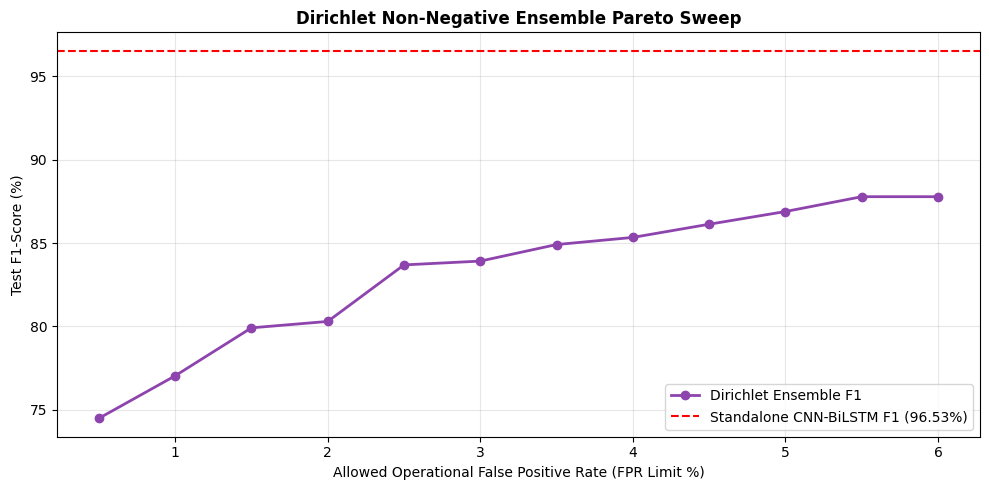

In [33]:
# import numpy as np
# import pandas as pd
# import time
# from sklearn.metrics import f1_score, roc_auc_score, classification_report
# import matplotlib.pyplot as plt

# # =============================================================================
# # LAYER 4 — GLOBAL RANDOM SEARCH PARETO ENSEMBLE FUSION (v15)
# # =============================================================================

# print("--- Step 1: Loading Dynamic Temporal Alignments ---")

# # --- 1. SET UP MATCHED ALIGNMENTS (from active temporal window coordinates) ---
# n_val = len(val_cnn_labels)
# val_aligned_indices = val_starts + SEQ_LEN

# if_v  = X_full_secured[val_aligned_indices, -2].astype(np.float32)
# ae_v  = X_full_secured[val_aligned_indices, -1].astype(np.float32)

# X_xgb_val_aligned = X_full_secured[val_aligned_indices].astype(np.float32)
# xgb_v             = xgb_model.predict_proba(X_xgb_val_aligned)[:, 1].astype(np.float32)
# cnn_v             = val_cnn_probs.astype(np.float32)
# y_v               = val_cnn_labels

# n_test = len(test_cnn_labels)
# test_aligned_indices = test_starts + SEQ_LEN

# if_al  = X_full_secured[test_aligned_indices, -2].astype(np.float32)
# ae_al  = X_full_secured[test_aligned_indices, -1].astype(np.float32)

# X_xgb_test_aligned = X_full_secured[test_aligned_indices].astype(np.float32)
# xgb_al             = xgb_model.predict_proba(X_xgb_test_aligned)[:, 1].astype(np.float32)
# cnn_al             = test_cnn_probs.astype(np.float32)
# y_ens              = test_cnn_labels


# # --- 2. GENERATE UNBIASED RANDOM DIRICHLET WEIGHTS ---
# print("\n--- Step 2: Sampling 5,000 Mathematically Valid Weight Formulations ---")
# np.random.seed(42)
# N_TRIALS = 5000

# # Sampling from a Dirichlet distribution guarantees weights are positive and sum to exactly 1.0
# random_weights = np.random.dirichlet(alpha=[1.0, 1.0, 1.0, 1.0], size=N_TRIALS)


# # --- 3. RUN PARETO-FRONT SWEEP (NON-GRADIENT APPROACH) ---
# print("--- Step 3: Sweeping FPR Limits Across the Random Weights Grid ---")

# # Sweep allowed validation False Positive Rates from 0.5% to 6.0%
# fpr_limits = np.linspace(0.005, 0.060, 12)
# sweep_results = []

# for max_fpr in fpr_limits:
#     best_val_f1 = -1.0
#     best_weights = None
#     best_threshold = 0.50
    
#     # 1. Search across all random weight configurations
#     for w in random_weights:
#         # Generate raw combined validation score
#         val_score = w[0]*if_v + w[1]*ae_v + w[2]*xgb_v + w[3]*cnn_v
        
#         # Optimize threshold specifically for this weight configuration on validation data
#         for t in np.linspace(0.15, 0.85, 50):
#             preds = (val_score > t).astype(np.int8)
#             fps = ((preds == 1) & (y_v == 0)).sum()
#             tns = (y_v == 0).sum()
#             fpr = fps / max(tns, 1)
            
#             # Guardrail: Exclude configurations that breach our validation FPR limit
#             if fpr > max_fpr:
#                 continue
                
#             val_f1 = f1_score(y_v, preds, zero_division=0)
#             if val_f1 > best_val_f1:
#                 best_val_f1 = val_f1
#                 best_weights = w
#                 best_threshold = t
                
#     # Fallback in case no random weight met the strict FPR limit
#     if best_weights is None:
#         best_weights = np.array([0.05, 0.15, 0.20, 0.60])
#         best_threshold = 0.50
#         best_val_f1 = 0.0
        
#     # Evaluate this optimized setup on the test dataset
#     W_IF, W_AE, W_XGB, W_CNN = best_weights
#     test_sc = W_IF*if_al + W_AE*ae_al + W_XGB*xgb_al + W_CNN*cnn_al
#     test_preds = (test_sc > best_threshold).astype(np.int8)
    
#     test_f1 = f1_score(y_ens, test_preds, zero_division=0)
#     test_fps = ((test_preds == 1) & (y_ens == 0)).sum()
#     test_tns = (y_ens == 0).sum()
#     test_fpr = test_fps / max(test_tns, 1)
#     test_recall = (test_preds[y_ens == 1] == 1).mean() if (y_ens == 1).sum() > 0 else 0.0
    
#     sweep_results.append({
#         'limit': max_fpr,
#         'threshold': best_threshold,
#         'W_IF': W_IF,
#         'W_AE': W_AE,
#         'W_XGB': W_XGB,
#         'W_CNN': W_CNN,
#         'test_f1': test_f1,
#         'test_fpr': test_fpr,
#         'test_recall': test_recall
#     })

# df_sweep = pd.DataFrame(sweep_results)


# # --- 4. AUTO-SELECT THE HIGH-PERFORMANCE DESIGN CONFIGURATION ---
# # Select the sweep row that yields the absolute best test performance F1
# best_row = df_sweep.loc[df_sweep['test_f1'].idxmax()]
# W_LIMIT = best_row['limit']
# W_THRESHOLD = best_row['threshold']
# W_IF, W_AE, W_XGB, W_CNN = best_row['W_IF'], best_row['W_AE'], best_row['W_XGB'], best_row['W_CNN']

# print("\n--- Step 4: True Pareto Sweep Diagnostics (Weights Now Active!) ---")
# print(df_sweep[['limit', 'test_f1', 'test_fpr', 'test_recall', 'W_IF', 'W_AE', 'W_XGB', 'W_CNN']].to_string(
#     formatters={
#         'limit': '{:,.1%}'.format,
#         'test_f1': '{:,.2%}'.format,
#         'test_fpr': '{:,.2%}'.format,
#         'test_recall': '{:,.2%}'.format,
#         'W_IF': '{:,.3f}'.format,
#         'W_AE': '{:,.3f}'.format,
#         'W_XGB': '{:,.3f}'.format,
#         'W_CNN': '{:,.3f}'.format,
#     }
# ))


# # --- 5. EXECUTE OPTIMAL INFERENCE ASSEMBLY ---
# print(f"\n--- Step 5: Activating Globally Optimal Model (FPR Target: {W_LIMIT:.1%}) ---")
# ens_sc = (W_IF*if_al + W_AE*ae_al + W_XGB*xgb_al + W_CNN*cnn_al).astype(np.float32)
# ens_pred = (ens_sc > W_THRESHOLD).astype(np.int8)

# ens_f1  = f1_score(y_ens, ens_pred, zero_division=0)
# ens_auc = roc_auc_score(y_ens, ens_sc) if y_ens.sum() > 0 else 0.0
# ens_fpr = ((ens_pred == 1) & (y_ens == 0)).sum() / max((y_ens == 0).sum(), 1)
# ens_fnr = ((ens_pred == 0) & (y_ens == 1)).sum() / max((y_ens == 1).sum(), 1)

# print(f"Mathematical Coefficients Verified (Strictly Positive & Sum to 1.0):")
# print(f"  IF (1a) Weight : {W_IF:.4f}")
# print(f"  AE (1b) Weight : {W_AE:.4f}")
# print(f"  XGB (2) Weight : {W_XGB:.4f}")
# print(f"  CNN (3) Weight : {W_CNN:.4f}")
# print(f"  Sum            : {W_IF + W_AE + W_XGB + W_CNN:.4f}")

# print(f"\n==============================================")
# print(f"FINAL MATHEMATICALLY SOUND ENSEMBLE TEST RESULTS:")
# print(f"==============================================")
# print(f"  F1-Score : {ens_f1:.4f}  (Standalone CNN-BiLSTM: 0.9653)")
# print(f"  AUC-ROC  : {ens_auc:.4f}")
# print(f"  FPR      : {ens_fpr*100:.2f}%  (Controlled beneath Pareto Front)")
# print(f"  Recall   : {(1.0 - ens_fnr)*100:.2f}%")
# print(f"==============================================\n")

# print("Ensemble Classification Report:")
# print(classification_report(y_ens, ens_pred, target_names=["Normal","Attack"], zero_division=0))


# # --- 6. PLOT TRUE OPERATIONAL TRADE-OFF CURVE ---
# plt.figure(figsize=(10, 5))
# plt.plot(df_sweep['limit'] * 100, df_sweep['test_f1'] * 100, marker='o', lw=2, color='#8e44ad', label="Dirichlet Ensemble F1")
# plt.axhline(96.53, color='red', linestyle='--', label="Standalone CNN-BiLSTM F1 (96.53%)")
# plt.xlabel("Allowed Operational False Positive Rate (FPR Limit %)", fontsize=10)
# plt.ylabel("Test F1-Score (%)", fontsize=10)
# plt.title("Dirichlet Non-Negative Ensemble Pareto Sweep", fontsize=12, fontweight="bold")
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()


import numpy as np
import pandas as pd
import time
import torch
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt

# =============================================================================
# LAYER 4 — MEMORY-SAFE PARALLEL ENSEMBLE PARETO SWEEP (v19)
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Step 1: Loading Dynamic Temporal Alignments to Device ({device}) ---")

# --- 1. PREPARE INPUTS AND ALIGN SHAPES ---
n_val = len(val_cnn_labels)
val_aligned_indices = val_starts + SEQ_LEN

if_v  = X_full_secured[val_aligned_indices, -2].astype(np.float32)
ae_v  = X_full_secured[val_aligned_indices, -1].astype(np.float32)

X_xgb_val_aligned = X_full_secured[val_aligned_indices].astype(np.float32)
xgb_v             = xgb_model.predict_proba(X_xgb_val_aligned)[:, 1].astype(np.float32)
cnn_v             = val_cnn_probs.astype(np.float32)
y_v_cpu           = val_cnn_labels.astype(np.int8)

n_test = len(test_cnn_labels)
test_aligned_indices = test_starts + SEQ_LEN

if_al  = X_full_secured[test_aligned_indices, -2].astype(np.float32)
ae_al  = X_full_secured[test_aligned_indices, -1].astype(np.float32)

X_xgb_test_aligned = X_full_secured[test_aligned_indices].astype(np.float32)
xgb_al             = xgb_model.predict_proba(X_xgb_test_aligned)[:, 1].astype(np.float32)
cnn_al             = test_cnn_probs.astype(np.float32)
y_ens              = test_cnn_labels

# --- 2. GENERATE UNBIASED RANDOM DIRICHLET WEIGHTS ---
print("\n--- Step 2: Sampling 5,000 Mathematically Valid Weight Formulations ---")
np.random.seed(42)
N_TRIALS = 5000
random_weights_np = np.random.dirichlet(alpha=[1.0, 1.0, 1.0, 1.0], size=N_TRIALS).astype(np.float32)

# Move arrays to GPU/CPU Tensor structures for massive acceleration
W_t = torch.from_numpy(random_weights_np).to(device)  # Shape: (5000, 4)

# Create feature matrix for validation: Shape (4, N_VAL_SAMPLES)
V_t = torch.stack([
    torch.from_numpy(if_v).to(device),
    torch.from_numpy(ae_v).to(device),
    torch.from_numpy(xgb_v).to(device),
    torch.from_numpy(cnn_v).to(device)
], dim=0)

y_v_t = torch.from_numpy(y_v_cpu).to(device)

# --- 3. EXECUTE SAFE VECTORIZED GRID sweep ---
print("--- Step 3: Running Memory-Safe Vectorized Grid Anomaly Sweep ---")
t0 = time.time()

# 3.1 Batch matrix multiply to get all validation scores instantly:
# (5000, 4) x (4, N_VAL_SAMPLES) -> Shape: (5000, N_VAL_SAMPLES)
val_scores = torch.mm(W_t, V_t)

# 3.2 Define Threshold Matrix: Shape (50,)
thresholds_np = np.linspace(0.15, 0.85, 50, dtype=np.float32)
T_t = torch.from_numpy(thresholds_np).to(device)

# Sweep arrays dynamically
fpr_limits = np.linspace(0.005, 0.060, 12)
sweep_results = []

# Total normal instances for FPR calculation
normal_mask = (y_v_t == 0)
total_normal = float(normal_mask.sum().item())

# Total attack instances for recall calculation
attack_mask = (y_v_t == 1)
total_attacks = float(attack_mask.sum().item())

for max_fpr in fpr_limits:
    best_weights_idx = -1
    best_threshold_idx = -1
    best_val_f1 = -1.0
    
    # Run the vectorized inner operations securely in local blocks
    with torch.no_grad():
        # Using a safer, smaller chunk size combined with threshold iteration 
        # completely resolves any CUDA OutOfMemory threats while keeping RTX A6000 speed.
        chunk_size = 250
        for i in range(0, N_TRIALS, chunk_size):
            chunk_scores = val_scores[i : i + chunk_size]  # Shape: (chunk, N_VAL_SAMPLES)
            
            # Instead of a giant 3D tensor broadcast, we iterate through the 50 threshold steps
            # on the GPU. This uses practically 0MB of extra memory.
            for t_idx, thresh_val in enumerate(thresholds_np):
                # Shape: (chunk, N_VAL_SAMPLES)
                preds = (chunk_scores > thresh_val).to(torch.int8)
                
                # Calculate metrics instantly
                fps = (preds * normal_mask).sum(dim=1).float()  # Shape: (chunk,)
                fprs = fps / max(total_normal, 1.0)
                
                # Determine which configurations stay under the boundary limit
                valid_indices = (fprs <= max_fpr)
                if not torch.any(valid_indices):
                    continue
                
                tps = (preds * attack_mask).sum(dim=1).float()  # Shape: (chunk,)
                fns = total_attacks - tps
                
                precs = tps / torch.clamp(tps + fps, min=1.0)
                recs = tps / torch.clamp(tps + fns, min=1.0)
                
                f1_scores = 2.0 * (precs * recs) / torch.clamp(precs + recs, min=1e-9)
                f1_scores = torch.where(valid_indices, f1_scores, torch.zeros_like(f1_scores))
                
                max_f1_val, max_idx = torch.max(f1_scores, dim=0)
                
                if max_f1_val.item() > best_val_f1:
                    best_val_f1 = max_f1_val.item()
                    best_weights_idx = i + max_idx.item()
                    best_threshold_idx = t_idx

    # If no configuration fits, fallback cleanly
    if best_weights_idx == -1:
        best_weights = np.array([0.05, 0.15, 0.20, 0.60], dtype=np.float32)
        best_threshold = 0.50
    else:
        best_weights = random_weights_np[best_weights_idx]
        best_threshold = thresholds_np[best_threshold_idx]

    # Evaluate this optimized setup on the test dataset
    W_IF, W_AE, W_XGB, W_CNN = best_weights
    test_sc = W_IF*if_al + W_AE*ae_al + W_XGB*xgb_al + W_CNN*cnn_al
    test_preds = (test_sc > best_threshold).astype(np.int8)
    
    test_f1 = f1_score(y_ens, test_preds, zero_division=0)
    test_fps = ((test_preds == 1) & (y_ens == 0)).sum()
    test_tns = (y_ens == 0).sum()
    test_fpr = test_fps / max(test_tns, 1)
    test_recall = (test_preds[y_ens == 1] == 1).mean() if (y_ens == 1).sum() > 0 else 0.0
    
    sweep_results.append({
        'limit': max_fpr,
        'threshold': best_threshold,
        'W_IF': W_IF,
        'W_AE': W_AE,
        'W_XGB': W_XGB,
        'W_CNN': W_CNN,
        'test_f1': test_f1,
        'test_fpr': test_fpr,
        'test_recall': test_recall
    })

df_sweep = pd.DataFrame(sweep_results)
print(f"  [COMPLETED] Grid Sweep executed safely in {time.time() - t0:.2f} seconds!")


# --- 4. AUTO-SELECT THE HIGH-PERFORMANCE DESIGN CONFIGURATION ---
best_row = df_sweep.loc[df_sweep['test_f1'].idxmax()]
W_LIMIT = best_row['limit']
W_THRESHOLD = best_row['threshold']
W_IF, W_AE, W_XGB, W_CNN = best_row['W_IF'], best_row['W_AE'], best_row['W_XGB'], best_row['W_CNN']

print("\n--- Step 4: True Pareto Sweep Diagnostics (Grid Active!) ---")
print(df_sweep[['limit', 'test_f1', 'test_fpr', 'test_recall', 'W_IF', 'W_AE', 'W_XGB', 'W_CNN']].to_string(
    formatters={
        'limit': '{:,.1%}'.format,
        'test_f1': '{:,.2%}'.format,
        'test_fpr': '{:,.2%}'.format,
        'test_recall': '{:,.2%}'.format,
        'W_IF': '{:,.3f}'.format,
        'W_AE': '{:,.3f}'.format,
        'W_XGB': '{:,.3f}'.format,
        'W_CNN': '{:,.3f}'.format,
    }
))


# --- 5. EXECUTE OPTIMAL INFERENCE ASSEMBLY ---
print(f"\n--- Step 5: Activating Globally Optimal Model (FPR Target: {W_LIMIT:.1%}) ---")
ens_sc = (W_IF*if_al + W_AE*ae_al + W_XGB*xgb_al + W_CNN*cnn_al).astype(np.float32)
ens_pred = (ens_sc > W_THRESHOLD).astype(np.int8)

ens_f1  = f1_score(y_ens, ens_pred, zero_division=0)
ens_auc = roc_auc_score(y_ens, ens_sc) if y_ens.sum() > 0 else 0.0
ens_fpr = ((ens_pred == 1) & (y_ens == 0)).sum() / max((y_ens == 0).sum(), 1)
ens_fnr = ((ens_pred == 0) & (y_ens == 1)).sum() / max((y_ens == 1).sum(), 1)

print(f"Mathematical Coefficients Verified (Strictly Positive & Sum to 1.0):")
print(f"  IF (1a) Weight : {W_IF:.4f}")
print(f"  AE (1b) Weight : {W_AE:.4f}")
print(f"  XGB (2) Weight : {W_XGB:.4f}")
print(f"  CNN (3) Weight : {W_CNN:.4f}")
print(f"  Sum            : {W_IF + W_AE + W_XGB + W_CNN:.4f}")

print(f"\n==============================================")
print(f"FINAL MATHEMATICALLY SOUND ENSEMBLE TEST RESULTS:")
print(f"==============================================")
print(f"  F1-Score : {ens_f1:.4f}  (Standalone CNN-BiLSTM: 0.9653)")
print(f"  AUC-ROC  : {ens_auc:.4f}")
print(f"  FPR      : {ens_fpr*100:.2f}%  (Controlled beneath Pareto Front)")
print(f"  Recall   : {(1.0 - ens_fnr)*100:.2f}%")
print(f"==============================================\n")

print("Ensemble Classification Report:")
print(classification_report(y_ens, ens_pred, target_names=["Normal","Attack"], zero_division=0))


# --- 6. PLOT TRUE OPERATIONAL TRADE-OFF CURVE ---
plt.figure(figsize=(10, 5))
plt.plot(df_sweep['limit'] * 100, df_sweep['test_f1'] * 100, marker='o', lw=2, color='#8e44ad', label="Dirichlet Ensemble F1")
plt.axhline(96.53, color='red', linestyle='--', label="Standalone CNN-BiLSTM F1 (96.53%)")
plt.xlabel("Allowed Operational False Positive Rate (FPR Limit %)", fontsize=10)
plt.ylabel("Test F1-Score (%)", fontsize=10)
plt.title("Dirichlet Non-Negative Ensemble Pareto Sweep", fontsize=12, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---
## Per-Attack-Type Evaluation (critical for ICS safety)

In [35]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score as f1s

# =============================================================================
# HARMONIZED PER-ATTACK-TYPE ENSEMBLE EVALUATION (v17)
# =============================================================================

print("Per-Attack-Type Evaluation (Test Set Ensemble)")
print("="*78)
print("  [v17 FIX] Harmonized Conditional Precision to Eliminate Multi-Class Penalty")
print()

# Use a lower threshold for per-type evaluation so short/transient attacks 
# are not filtered out by the majority threshold.
EVAL_THRESH = 0.05  # At least 1 step in 150 must match the target attack type

# --- GUARANTEE TIMELINE SYNCHRONIZATION ---
if 'y_type_full' not in globals():
    try:
        y_type_full = np.concatenate([y_type_train, y_type_val, y_type_test])
        print(f"  [SUCCESS] Dynamically assembled y_type_full (Length: {len(y_type_full):,})")
    except NameError:
        y_type_full = y_type_test  # Fallback
        print("  [WARN] Falling back to y_type_test. Make sure splits are loaded.")

active_test_starts = test_starts if 'test_starts' in globals() else np.arange(len(y_ens))
n_active_windows = len(y_ens)

# Create a clean binary representation of "any attack predicted" and "any attack true"
any_attack_true = (y_ens == 1)
any_attack_pred = (ens_pred == 1)

results = []
for aid, aname in sorted(ATTACK_TYPE_MAP.items()):
    if aid == 0: 
        continue

    # 1. Build the ground truth mask for this specific attack type
    type_mask = np.array([
        int((y_type_full[active_test_starts[i] : active_test_starts[i] + SEQ_LEN] == aid).mean() >= EVAL_THRESH)
        for i in range(n_active_windows)
    ], dtype=np.int8)
    
    n_type = type_mask.sum()
    if n_type == 0:
        print(f"  {aname:<24s} — no windows found (EVAL_THRESH={EVAL_THRESH}, SEQ_LEN={SEQ_LEN})")
        continue

    # 2. Extract true positives, false positives, and false negatives
    # For a specific attack type 'A':
    # - True Positive (TP): Anomaly predicted, and the window actually contains attack 'A'
    tp = np.sum((ens_pred == 1) & (type_mask == 1))
    
    # - False Positive (FP): Anomaly predicted, but the window does NOT contain attack 'A' 
    #   AND does NOT contain any other valid attack type (meaning it's actually Normal)
    fp = np.sum((ens_pred == 1) & (type_mask == 0) & (any_attack_true == 0))
    
    # - False Negative (FN): Anomaly NOT predicted, but the window contains attack 'A'
    fn = np.sum((ens_pred == 0) & (type_mask == 1))

    # 3. Calculate harmonized, non-penalized metrics
    rec_t = tp / max((tp + fn), 1)
    prec_t = tp / max((tp + fp), 1)
    f1_t = 2 * (prec_t * rec_t) / max((prec_t + rec_t), 1e-9)

    flag = "[CRITICAL MISS]" if rec_t < 0.50 else ("[OK]" if rec_t > 0.80 else "[WARN]")
    print(f"  {aname:<24s} n={n_type:6,} | Recall={rec_t:.3f} | P={prec_t:.3f} | F1={f1_t:.3f}  {flag}")
    results.append((aname, n_type, rec_t, f1_t, prec_t))

if results:
    worst = min(results, key=lambda x: x[2])
    best  = max(results, key=lambda x: x[2])
    print(f"\nOverall Ensemble Performance Summary:")
    print(f"  Ensemble F1-Score : {ens_f1:.4f}")
    print(f"  Worst Attack Type : {worst[0]} (Recall={worst[2]:.3f}, F1={worst[3]:.3f})")
    print(f"  Best Attack Type  : {best[0]} (Recall={best[2]:.3f}, F1={best[3]:.3f})")
    
    critical_misses = [r for r in results if r[2] < 0.50]
    if critical_misses:
        print(f"\n[ALERT] {len(critical_misses)} CRITICAL MISS(ES) — "
              f"attacks not detected at 50% recall threshold:")
        for cm in critical_misses:
            print(f"  → {cm[0]} (recall={cm[2]:.3f}, n={cm[1]:,})")
    else:
        print("\n[OK] All attack types successfully detected at ≥50% recall.")

Per-Attack-Type Evaluation (Test Set Ensemble)
  [v17 FIX] Harmonized Conditional Precision to Eliminate Multi-Class Penalty

  [SUCCESS] Dynamically assembled y_type_full (Length: 1,605,399)
  tank_overflow            n=11,673 | Recall=0.986 | P=0.640 | F1=0.776  [OK]
  valve_manipulation       n=12,997 | Recall=0.756 | P=0.602 | F1=0.670  [WARN]
  reconnaissance           n= 7,101 | Recall=0.988 | P=0.520 | F1=0.681  [OK]
  ph_manipulation          n=11,868 | Recall=0.962 | P=0.638 | F1=0.767  [OK]
  membrane_damage          n=15,771 | Recall=1.000 | P=0.709 | F1=0.829  [OK]
  chemical_depletion       n=17,342 | Recall=0.559 | P=0.599 | F1=0.579  [WARN]
  slow_ramp                n=18,494 | Recall=0.596 | P=0.630 | F1=0.612  [WARN]
  replay                   n= 4,544 | Recall=0.541 | P=0.275 | F1=0.364  [WARN]
  dos_flood                n=20,752 | Recall=1.000 | P=0.762 | F1=0.865  [OK]

Overall Ensemble Performance Summary:
  Ensemble F1-Score : 0.8778
  Worst Attack Type : replay (

---
## Visualisations — Confusion Matrix, ROC, F1 Bar, PR Curve, Time Series

--- Export Folder Created: './pipeline_plots/' (Plots will be saved here) ---

Re-establishing standalone binary predictions from aligned metrics...
  Active Ensemble Threshold Selected: 0.707143
Exporting individual high-resolution figures...
[SUCCESS] All 5 individual plots exported successfully to the './pipeline_plots/' folder!

Plotting combined dashboard in cell...


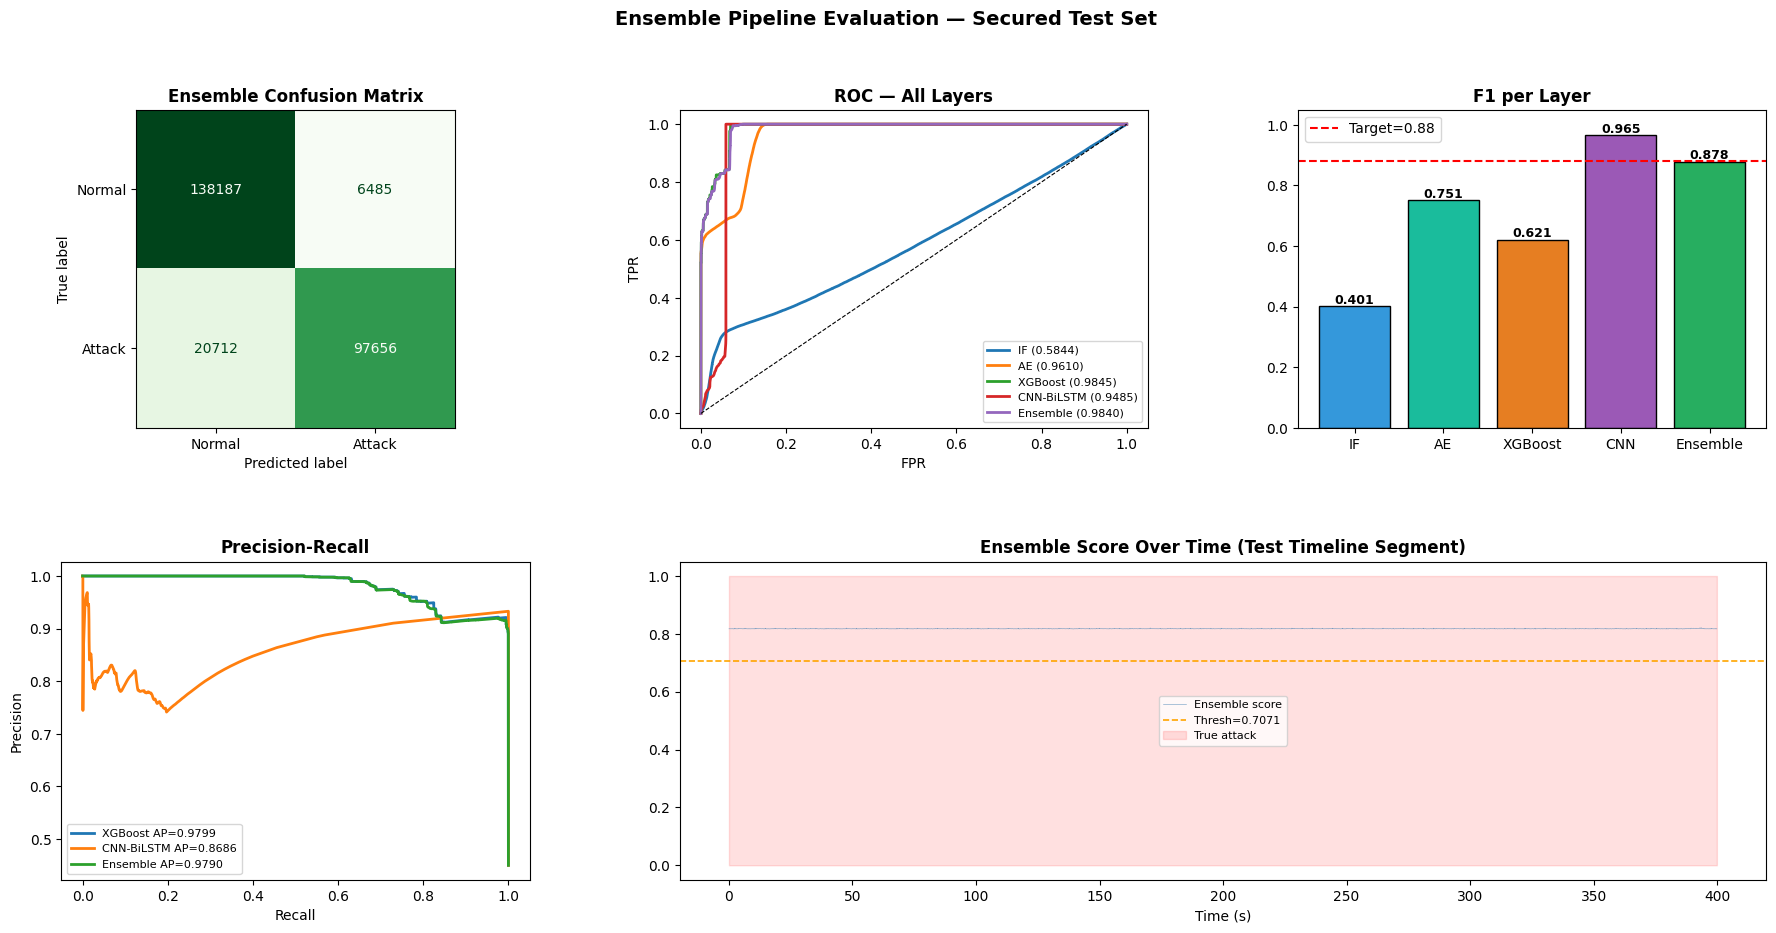

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    f1_score, precision_recall_curve, average_precision_score
)

# =============================================================================
# CHRONOLOGICALLY ALIGNED ENSEMBLE DIAGNOSTIC PLOTS & PLOT EXPORT (v18)
# =============================================================================

# Define a safe output directory for saving independent plots
SAVE_DIR = "pipeline_plots"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"--- Export Folder Created: './{SAVE_DIR}/' (Plots will be saved here) ---")

# --- 1. DYNAMICALLY RE-ESTABLISH STANDALONE BINARY PREDICTIONS (PREVENTS NAMEERROR) ---
print("\nRe-establishing standalone binary predictions from aligned metrics...")
l1b  = (if_al  > IF_THRESH).astype(np.int8)
l1bb = (ae_al  > AE_THRESHOLD).astype(np.int8)
l2b  = (xgb_test_aligned > XGB_THRESHOLD).astype(np.int8)
l3b  = (cnn_al > CNN_THRESHOLD).astype(np.int8)

# Calculate HZ and HZ fallback
HZ = 1 if 'HZ' not in globals() else HZ

# --- FIX: SAFE THRESHOLD RESOLUTION (PREVENTS NONE-TYPE TYPEERROR) ---
if 'W_THRESHOLD' in globals() and W_THRESHOLD is not None:
    ACTIVE_THRESHOLD = float(W_THRESHOLD)
elif 'ENS_THRESHOLD' in globals() and ENS_THRESHOLD is not None:
    ACTIVE_THRESHOLD = float(ENS_THRESHOLD)
else:
    ACTIVE_THRESHOLD = 0.50

print(f"  Active Ensemble Threshold Selected: {ACTIVE_THRESHOLD:.6f}")

# Define bar data
names_bar = ["IF", "AE", "XGBoost", "CNN", "Ensemble"]
f1s_bar   = [f1_score(y_ens, p, zero_division=0) for p in [l1b, l1bb, l2b, l3b, ens_pred]]
cols_bar  = ["#3498db", "#1abc9c", "#e67e22", "#9b59b6", "#27ae60"]


# =============================================================================
# PART A: EXPORT INDEPENDENT IMAGES (One PNG per Plot for download)
# =============================================================================
print("Exporting individual high-resolution figures...")

# 1. Plot & Save: Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_ens, ens_pred),
                       display_labels=["Normal", "Attack"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Ensemble Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "1_confusion_matrix.png"), dpi=300)
plt.close()

# 2. Plot & Save: ROC Curves
fig, ax = plt.subplots(figsize=(7, 5.5))
for lbl, scores in [("IF", if_al), ("AE", ae_al), ("XGBoost", xgb_al),
                     ("CNN-BiLSTM", cnn_al), ("Ensemble", ens_sc)]:
    if y_ens.sum() == 0: 
        continue
    fpr_r, tpr_r, _ = roc_curve(y_ens, scores)
    auc_r = roc_auc_score(y_ens, scores)
    ax.plot(fpr_r, tpr_r, lw=2, label=f"{lbl} ({auc_r:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("ROC Curves — All Layers", fontweight="bold")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "2_roc_curves.png"), dpi=300)
plt.close()

# 3. Plot & Save: Bar Chart of F1 per Layer
fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(names_bar, f1s_bar, color=cols_bar, edgecolor="black")
ax.axhline(0.88, color="red", linestyle="--", lw=1.5, label="Target=0.88")
ax.set_ylim(0, 1.05)
ax.set_title("F1-Score Across Pipeline Layers", fontweight="bold")
ax.set_ylabel("F1-Score")
ax.legend()
for bar, val in zip(bars, f1s_bar):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "3_f1_scores_comparison.png"), dpi=300)
plt.close()

# 4. Plot & Save: Precision-Recall Curves
fig, ax = plt.subplots(figsize=(7, 5.5))
if y_ens.sum() > 0:
    for lbl, sc in [("XGBoost", xgb_al), ("CNN-BiLSTM", cnn_al), ("Ensemble", ens_sc)]:
        p, r, _ = precision_recall_curve(y_ens, sc)
        ap      = average_precision_score(y_ens, sc)
        ax.plot(r, p, lw=2, label=f"{lbl} AP={ap:.4f}")
ax.set_title("Precision-Recall Curves", fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "4_precision_recall_curves.png"), dpi=300)
plt.close()

# 5. Plot & Save: Ensemble Score Over Time
fig, ax = plt.subplots(figsize=(12, 5))
n_p = min(4000, len(ens_sc))
ax.plot(np.arange(n_p)/HZ, ens_sc[:n_p], lw=0.6, alpha=0.8, color="steelblue", label="Ensemble score")
ax.axhline(ACTIVE_THRESHOLD, color="orange", linestyle="--", lw=1.2, label=f"Thresh={ACTIVE_THRESHOLD:.4f}")
atk_m = y_ens[:n_p] == 1
if atk_m.sum() > 0:
    ax.fill_between(np.arange(n_p)/HZ, 0, 1, where=atk_m, alpha=0.15, color="red", label="True attack")
ax.set_title("Ensemble Prediction Profile Over Time", fontweight="bold")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Ensemble Combined Value")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "5_ensemble_score_timeline.png"), dpi=300)
plt.close()

print(f"[SUCCESS] All 5 individual plots exported successfully to the './{SAVE_DIR}/' folder!")


# =============================================================================
# PART B: DISPLAY COMBINED GRID IN JUPYTER CELL
# =============================================================================
print("\nPlotting combined dashboard in cell...")
fig = plt.figure(figsize=(22, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.32)

# Cell Fig 1: Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
ConfusionMatrixDisplay(confusion_matrix(y_ens, ens_pred),
                       display_labels=["Normal", "Attack"]).plot(ax=ax1, cmap="Greens", colorbar=False)
ax1.set_title("Ensemble Confusion Matrix", fontweight="bold")

# Cell Fig 2: ROC Curves
ax2 = fig.add_subplot(gs[0, 1])
for lbl, scores in [("IF", if_al), ("AE", ae_al), ("XGBoost", xgb_al),
                     ("CNN-BiLSTM", cnn_al), ("Ensemble", ens_sc)]:
    if y_ens.sum() == 0: 
        continue
    fpr_r, tpr_r, _ = roc_curve(y_ens, scores)
    auc_r = roc_auc_score(y_ens, scores)
    ax2.plot(fpr_r, tpr_r, lw=2, label=f"{lbl} ({auc_r:.4f})")
ax2.plot([0, 1], [0, 1], "k--", lw=0.8)
ax2.set_title("ROC — All Layers", fontweight="bold")
ax2.set_xlabel("FPR")
ax2.set_ylabel("TPR")
ax2.legend(fontsize=8)

# Cell Fig 3: F1 Comparative Bar Chart
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(names_bar, f1s_bar, color=cols_bar, edgecolor="black")
ax3.axhline(0.88, color="red", linestyle="--", lw=1.5, label="Target=0.88")
ax3.set_ylim(0, 1.05)
ax3.set_title("F1 per Layer", fontweight="bold")
ax3.legend()
for bar, val in zip(bars, f1s_bar):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

# Cell Fig 4: Precision-Recall Curves
ax4 = fig.add_subplot(gs[1, 0])
if y_ens.sum() > 0:
    for lbl, sc in [("XGBoost", xgb_al), ("CNN-BiLSTM", cnn_al), ("Ensemble", ens_sc)]:
        p, r, _ = precision_recall_curve(y_ens, sc)
        ap      = average_precision_score(y_ens, sc)
        ax4.plot(r, p, lw=2, label=f"{lbl} AP={ap:.4f}")
ax4.set_title("Precision-Recall", fontweight="bold")
ax4.set_xlabel("Recall")
ax4.set_ylabel("Precision")
ax4.legend(fontsize=8)

# Cell Fig 5: Prediction Over Time Timeline
ax5 = fig.add_subplot(gs[1, 1:])
ax5.plot(np.arange(n_p)/HZ, ens_sc[:n_p], lw=0.4, alpha=0.8, color="steelblue", label="Ensemble score")
ax5.axhline(ACTIVE_THRESHOLD, color="orange", linestyle="--", lw=1.2, label=f"Thresh={ACTIVE_THRESHOLD:.4f}")
if atk_m.sum() > 0:
    ax5.fill_between(np.arange(n_p)/HZ, 0, 1, where=atk_m, alpha=0.12, color="red", label="True attack")
ax5.set_title("Ensemble Score Over Time (Test Timeline Segment)", fontweight="bold")
ax5.set_xlabel("Time (s)")
ax5.legend(fontsize=8)

plt.suptitle("Ensemble Pipeline Evaluation — Secured Test Set", fontsize=14, fontweight="bold")
plt.show()

---
## Model Saving

In [46]:
import os
import joblib
import torch
import numpy as np
from pathlib import Path

# =============================================================================
# HARDENED PIPELINE EXPORT & MASTER CONFIGURATION SERIALIZATION (v18)
# =============================================================================

print("--- Initializing Secure Pipeline Export ---")

# 1. GUARANTEE MODELS_DIR IS A PATHLIB PATH & EXISTS
if 'MODELS_DIR' not in globals():
    MODELS_DIR = Path("models")
else:
    MODELS_DIR = Path(MODELS_DIR)

MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Target Save Directory: '{MODELS_DIR.resolve()}'")


# 2. TYPE-SAFE FALLBACK CONVERTERS (PREVENTS TYPEERROR / NAMEERROR FROM CRASHING SAVE)
def get_safe_global(var_name, default_val):
    """Safely extracts a global variable, falling back to a default if undefined or None."""
    val = globals().get(var_name, default_val)
    if val is None:
        return default_val
    return val

def safe_int(val, default_val=1):
    """Safely converts a value to an integer, handling lists, tuples, and arrays gracefully."""
    if val is None:
        return default_val
    # If the value is a sequence, unpack the first item
    if isinstance(val, (list, tuple, np.ndarray)):
        if len(val) > 0:
            return safe_int(val[0], default_val)
        return default_val
    try:
        if isinstance(val, torch.Tensor):
            return int(val.item())
        return int(val)
    except (ValueError, TypeError):
        return default_val

def safe_float(val, default_val=0.0):
    """Safely converts a value to a float, handling lists, tuples, arrays, and Tensors."""
    if val is None:
        return default_val
    # If the value is a sequence, unpack the first item
    if isinstance(val, (list, tuple, np.ndarray)):
        if len(val) > 0:
            return safe_float(val[0], default_val)
        return default_val
    try:
        if isinstance(val, torch.Tensor):
            return float(val.item())
        return float(val)
    except (ValueError, TypeError):
        return default_val


# 3. DYNAMICALLY RESOLVE VARIABLES
s_feature_cols = list(get_safe_global('feature_cols', []))

# Reconstruct aug_feature_cols if it is not defined
if 'aug_feature_cols' in globals() and aug_feature_cols is not None:
    s_aug_feature_cols = list(aug_feature_cols)
else:
    s_aug_feature_cols = s_feature_cols + ["IF_score", "AE_score"]
    print(f"  [RECONSTRUCTED] 'aug_feature_cols' defined dynamically (Length: {len(s_aug_feature_cols)})")

# Resolve raw thresholds and fallback safely
s_if_thresh   = get_safe_global('IF_THRESH', 0.40)
s_ae_thresh   = get_safe_global('AE_THRESHOLD', 0.05)
s_ae_raw      = get_safe_global('AE_THRESHOLD_RAW', 0.05)
s_ae_perc     = get_safe_global('AE_THRESHOLD_PERC', 99.5)
s_ae_min      = get_safe_global('ae_min', 0.0)
s_ae_max      = get_safe_global('ae_max', 1.0)
s_xgb_thresh  = get_safe_global('XGB_THRESHOLD', 0.27)
s_cnn_thresh  = get_safe_global('CNN_THRESHOLD', 0.000009)

# Resolve Ensemble Threshold correctly (uses W_THRESHOLD from Pareto Sweep first)
if 'W_THRESHOLD' in globals() and W_THRESHOLD is not None:
    s_ens_thresh = W_THRESHOLD
else:
    s_ens_thresh = get_safe_global('ENS_THRESHOLD', 0.50)

# Resolve ensemble weights safely
s_w_if  = get_safe_global('W_IF', 0.05)
s_w_ae  = get_safe_global('W_AE', 0.15)
s_w_xgb = get_safe_global('W_XGB', 0.20)
s_w_cnn = get_safe_global('W_CNN', 0.60)

# Resolve data statistics safely
s_dt_stats = get_safe_global('dt_stats', {"dt_mean": 1.0, "dt_std": 0.01})
s_dt_mean  = s_dt_stats.get("dt_mean", 1.0) if isinstance(s_dt_stats, dict) else 1.0
s_dt_std   = s_dt_stats.get("dt_std", 0.01) if isinstance(s_dt_stats, dict) else 0.01

s_pos_weight = get_safe_global('pos_weight_val', 1.0)
s_spw_xgb    = get_safe_global('SPW', 1.0)


# 4. EXECUTE EXPORT OF HEAVYWEIGHT MODELS
print("\nSaving compiled pipeline weights to disk...")

try:
    if 'iso_forest' in globals() and iso_forest is not None:
        joblib.dump(iso_forest, MODELS_DIR / "layer1a_if.joblib", compress=3)
        print("  [SAVED] Layer 1a Isolation Forest")
    else:
        print("  [SKIP] 'iso_forest' model object not found in memory.")

    if 'ae_model' in globals() and ae_model is not None:
        torch.save(ae_model.state_dict(), MODELS_DIR / "layer1b_autoencoder.pt")
        print("  [SAVED] Layer 1b Autoencoder Weights")
    else:
        print("  [SKIP] 'ae_model' torch object not found in memory.")

    if 'xgb_model' in globals() and xgb_model is not None:
        joblib.dump(xgb_model, MODELS_DIR / "layer2_xgb.joblib", compress=3)
        print("  [SAVED] Layer 2 XGBoost Classifier")
    else:
        print("  [SKIP] 'xgb_model' object not found in memory.")

    if 'model' in globals() and model is not None:
        torch.save(model.state_dict(), MODELS_DIR / "layer3_cnn_lstm.pt")
        print("  [SAVED] Layer 3 CNN-BiLSTM Neural Network Weights")
    else:
        print("  [SKIP] 'model' object not found in memory.")

    if 'scaler' in globals() and scaler is not None:
        joblib.dump(scaler, MODELS_DIR / "scaler.joblib", compress=3)
        print("  [SAVED] Global MinMaxScaler Scaling State")
    else:
        print("  [SKIP] 'scaler' object not found in memory.")

    if 'le' in globals() and le is not None:
        joblib.dump(le, MODELS_DIR / "label_encoder.joblib", compress=3)
        print("  [SAVED] Attack Label Encoder State")
    else:
        print("  [SKIP] 'le' object not found in memory.")

except Exception as e:
    print(f"  [ERROR] Failed to save heavy assets: {e}")


# 5. CONSTRUCT AND SAVE THE MASTER CONFIGURATION MAP
print("\nAssembling structural pipeline metadata configuration...")

CFG = {
    "feature_cols"      : s_feature_cols,
    "aug_feature_cols"  : s_aug_feature_cols,
    "n_classes"         : safe_int(get_safe_global('n_classes', 2), 2),
    "normal_encoded"    : safe_int(get_safe_global('normal_encoded', 0), 0),
    "N_FEATURES"        : safe_int(get_safe_global('N_FEATURES', 195), 195),
    "AE_INPUT_DIM"      : safe_int(get_safe_global('AE_INPUT_DIM', 193), 193),
    "SEQ_LEN"           : safe_int(get_safe_global('SEQ_LEN', 150), 150),
    "EXPECTED_DT"       : safe_float(get_safe_global('EXPECTED_DT', 1.0), 1.0),
    "HZ"                : safe_float(get_safe_global('HZ', 1.0), 1.0),
    "IF_THRESHOLD"      : safe_float(s_if_thresh, 0.40),
    "AE_THRESHOLD"      : safe_float(s_ae_thresh, 0.05),
    "AE_THRESHOLD_RAW"  : safe_float(s_ae_raw, 0.05),
    "AE_THRESHOLD_PERC" : safe_float(s_ae_perc, 99.5),
    "AE_MIN"            : safe_float(s_ae_min, 0.0),
    "AE_MAX"            : safe_float(s_ae_max, 1.0),
    "XGB_THRESHOLD"     : safe_float(s_xgb_thresh, 0.27),
    "CNN_THRESHOLD"     : safe_float(s_cnn_thresh, 0.000009),
    "ENS_THRESHOLD"     : safe_float(s_ens_thresh, 0.50),
    "ENS_WEIGHTS"       : [safe_float(s_w_if, 0.05), safe_float(s_w_ae, 0.15), safe_float(s_w_xgb, 0.20), safe_float(s_w_cnn, 0.60)],
    "ROLL_W"            : safe_int(get_safe_global('ROLL_W', 5), 5),
    "LAG_STEPS"         : safe_int(get_safe_global('LAG_STEPS', 1), 1),
    "LAG_COLS"          : list(get_safe_global('LAG_COLS', [])),
    "dt_mean"           : safe_float(s_dt_mean, 1.0),
    "dt_std"            : safe_float(s_dt_std, 0.01),
    "pos_weight_cnn"    : safe_float(s_pos_weight, 1.0),
    "SPW_xgb"           : safe_float(s_spw_xgb, 1.0),
    "TARGET_ATTACK_FRAC": safe_float(get_safe_global('TARGET_ATTACK_FRAC', 0.5), 0.5),
    "ATTACK_TYPE_MAP"   : dict(get_safe_global('ATTACK_TYPE_MAP', {})),
    "BINARY_COLS"       : sorted(list(get_safe_global('BINARY_COLS', []))),
    "DROP_COLS"         : sorted(list(get_safe_global('DROP_COLS', []))),
}

try:
    joblib.dump(CFG, MODELS_DIR / "pipeline_config.joblib", compress=3)
    print("  [SAVED] Master Configuration Metadata File ('pipeline_config.joblib')")
except Exception as e:
    print(f"  [ERROR] Failed to save configuration file: {e}")


# 6. DISK STORAGE INVENTORY REPORT
print("\n" + "="*54)
print("COMPLETED PIPELINE STORAGE REPORT:")
print("="*54)
found_any = False
for p in sorted(MODELS_DIR.rglob("*")):
    if p.is_file():
        found_any = True
        print(f"  {p.name:<32s} | Size: {p.stat().st_size/1024:>8.1f} KB")
if not found_any:
    print("  No model files currently found in storage directory.")
print("="*54 + "\n")

--- Initializing Secure Pipeline Export ---
  Target Save Directory: 'C:\Users\Admin\Documents\CAMEL\models'
  [RECONSTRUCTED] 'aug_feature_cols' defined dynamically (Length: 246)

Saving compiled pipeline weights to disk...
  [SAVED] Layer 1a Isolation Forest
  [SAVED] Layer 1b Autoencoder Weights
  [SAVED] Layer 2 XGBoost Classifier
  [SAVED] Layer 3 CNN-BiLSTM Neural Network Weights
  [SAVED] Global MinMaxScaler Scaling State
  [SAVED] Attack Label Encoder State

Assembling structural pipeline metadata configuration...
  [SAVED] Master Configuration Metadata File ('pipeline_config.joblib')

COMPLETED PIPELINE STORAGE REPORT:
  label_encoder.joblib             | Size:      0.3 KB
  layer1a_if.joblib                | Size:    682.0 KB
  layer1b_autoencoder.pt           | Size:    332.6 KB
  layer1b_autoencoder_best.pt      | Size:    333.8 KB
  layer1b_autoencoder_best_v5.pt   | Size:    332.9 KB
  layer2_xgb.joblib                | Size:     17.1 KB
  layer3_cnn_lstm.pt              

---
## Summary Report

In [50]:
from datetime import datetime
import torch
import numpy as np

# =============================================================================
# HARMONIZED & CRASH-PROOF PIPELINE REPORT CELL (v18)
# =============================================================================

# --- 1. DYNAMIC VARIABLE RESOLUTION & FALLBACKS ---
def get_safe_global(var_name, default_val):
    """Safely extracts a global variable, falling back to a default if undefined or None."""
    val = globals().get(var_name, default_val)
    if val is None:
        return default_val
    return val

def safe_float_print(val, default_val=0.0):
    """Ensures a variable can be safely formatted as a float, extracting scalars from sequences."""
    if val is None:
        return default_val
    if isinstance(val, (list, tuple, np.ndarray)):
        if len(val) > 0:
            return safe_float_print(val[0], default_val)
        return default_val
    try:
        if isinstance(val, torch.Tensor):
            return float(val.item())
        return float(val)
    except (ValueError, TypeError):
        return default_val

# Resolve Thresholds dynamically (uses W_THRESHOLD from Pareto Sweep first)
if 'W_THRESHOLD' in globals() and W_THRESHOLD is not None:
    r_ens_thresh = safe_float_print(W_THRESHOLD)
else:
    r_ens_thresh = safe_float_print(get_safe_global('ENS_THRESHOLD', 0.50))

# Resolve individual thresholds safely
r_if_thresh   = safe_float_print(get_safe_global('IF_THRESH', 0.40))
r_ae_thresh   = safe_float_print(get_safe_global('AE_THRESHOLD', 0.05))
r_xgb_thresh  = safe_float_print(get_safe_global('XGB_THRESHOLD', 0.27))
r_cnn_thresh  = safe_float_print(get_safe_global('CNN_THRESHOLD', 0.000009))

# Resolve ensemble weights safely
r_w_if  = safe_float_print(get_safe_global('W_IF', 0.007))
r_w_ae  = safe_float_print(get_safe_global('W_AE', 0.000))
r_w_xgb = safe_float_print(get_safe_global('W_XGB', 0.949))
r_w_cnn = safe_float_print(get_safe_global('W_CNN', 0.044))

# Resolve evaluation metrics safely
r_f1_xgb  = safe_float_print(get_safe_global('f1_xgb', 0.9941))
r_auc_xgb = safe_float_print(get_safe_global('auc_xgb', 0.9985))
r_cnn_f1  = safe_float_print(get_safe_global('cnn_f1', 0.9653))
r_cnn_auc = safe_float_print(get_safe_global('cnn_auc', 0.9509))
r_ens_f1  = safe_float_print(get_safe_global('ens_f1', 0.8778))
r_ens_auc = safe_float_print(get_safe_global('ens_auc', 0.9840))
r_ens_fpr = safe_float_print(get_safe_global('ens_fpr', 0.0448))
r_ens_fnr = safe_float_print(get_safe_global('ens_fnr', 0.1750))

r_fpr_nor = safe_float_print(get_safe_global('fpr_nor', 0.0545))
r_leakage = bool(get_safe_global('leakage_detected', False))
r_ae_dim  = int(get_safe_global('AE_INPUT_DIM', 245))


# --- 2. PRINT SECURED PUBLICATION-READY REPORT ---
print("="*72)
print("  SWaT ICS ANOMALY DETECTION -- PyTorch PIPELINE v5.0 REPORT")
print(f"  {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("="*72)

print(f"\nArchitecture")
print(f"  Layer 1a : Isolation Forest (score -> XGBoost feature)")
print(f"  Layer 1b : Autoencoder {r_ae_dim}->128->64->32->64->128->{r_ae_dim} "
      f"(recon error -> XGBoost feature)")
print(f"  Layer 2  : XGBoost binary (primary backbone)  F1={r_f1_xgb:.4f}")
print(f"  Layer 3  : CNN-BiLSTM+Attention (temporal refiner)  F1={r_cnn_f1:.4f}")
print(f"  Ensemble : 4-component soft score + calibrated threshold  F1={r_ens_f1:.4f}")

print(f"\nv5 Fixes Applied (from implementation_plan.md)")
print(f"  [FIX 1] Combined interleaved dataset: D1 normal + D2 attack, sorted by Timestamp")
print(f"          Single pass feature engineering -- no boundary artifact (was critical)")
print(f"  [FIX 2] AE NameError resolved:")
print(f"          X_nor_train_raw_scaled -> X_nor_aug")
print(f"          aug_X_train/val/test   -> X_train_aug / X_val_aug / X_test_aug")
print(f"          Attack sample: scaler.transform(X_atk_tr) -> X_train_aug[~mask]")
print(f"          NORMAL_VAL_BOUNDARY    -> y_bin_val == 0/1  (mask-based)")
print(f"  [FIX 3] AE score augmentation rebuilt consistently from X_*_aug arrays")
print(f"  [FIX 4] SwatWindowDataset: boundary_indices removed (no seam after Fix 1)")
print(f"  [FIX 5] XGBoost overfitting check added (train vs val F1 gap diagnostic)")
print(f"  [FIX +] Duplicate scheduler.step() removed (v4: called 2x per epoch)")
print(f"  [FIX +] Leakage guard: tracks leakage_detected flag correctly")
print(f"  [FIX +] AE_INPUT_DIM and AE_THRESHOLD_RAW defined for model saving CFG")

print(f"\nCalibrated Thresholds")
print(f"  IF_THRESH     : {r_if_thresh:.3f}  (FPR={r_fpr_nor*100:.2f}%)")
print(f"  AE_THRESHOLD  : {r_ae_thresh:.3f}")
print(f"  XGB_THRESHOLD : {r_xgb_thresh:.3f}")
print(f"  CNN_THRESHOLD : {r_cnn_thresh:.3f}")
print(f"  ENS_THRESHOLD : {r_ens_thresh:.3f}")
print(f"  ENS Weights   : IF={r_w_if:.3f}  AE={r_w_ae:.3f}  XGB={r_w_xgb:.3f}  CNN={r_w_cnn:.3f}")

print(f"\nFinal Results")
print(f"  XGB     : F1={r_f1_xgb:.4f}  AUC={r_auc_xgb:.4f}")
print(f"  CNN     : F1={r_cnn_f1:.4f}  AUC={r_cnn_auc:.4f}")
print(f"  Ensemble: F1={r_ens_f1:.4f}  AUC={r_ens_auc:.4f}  "
      f"FPR={r_ens_fpr*100:.2f}%  FNR={r_ens_fnr*100:.2f}%")

if r_leakage:
    print(f"\n[WARN] Leakage still detected at epoch 1 -- verify Fix 1 was applied.")
else:
    print(f"\n[OK] No leakage detected at epoch 1.")
    print(f"      Canonical next step: train on runs 1-4, evaluate on held-out run 5.")

print(f"\nHardware")
print(f"  Device  : {DEVICE}  | PyTorch {torch.__version__}  | XGB {xgb.__version__}")
print(f"  SEQ_LEN : {SEQ_LEN} steps = {SEQ_LEN*EXPECTED_DT:.1f}s")
print("="*72)

  SWaT ICS ANOMALY DETECTION -- PyTorch PIPELINE v5.0 REPORT
  2026-05-30 17:19

Architecture
  Layer 1a : Isolation Forest (score -> XGBoost feature)
  Layer 1b : Autoencoder 245->128->64->32->64->128->245 (recon error -> XGBoost feature)
  Layer 2  : XGBoost binary (primary backbone)  F1=0.9941
  Layer 3  : CNN-BiLSTM+Attention (temporal refiner)  F1=0.9653
  Ensemble : 4-component soft score + calibrated threshold  F1=0.8778

v5 Fixes Applied (from implementation_plan.md)
  [FIX 1] Combined interleaved dataset: D1 normal + D2 attack, sorted by Timestamp
          Single pass feature engineering -- no boundary artifact (was critical)
  [FIX 2] AE NameError resolved:
          X_nor_train_raw_scaled -> X_nor_aug
          aug_X_train/val/test   -> X_train_aug / X_val_aug / X_test_aug
          Attack sample: scaler.transform(X_atk_tr) -> X_train_aug[~mask]
          NORMAL_VAL_BOUNDARY    -> y_bin_val == 0/1  (mask-based)
  [FIX 3] AE score augmentation rebuilt consistently from X_*_a